# Travel Reimbursement Approval Agent

**AI Developer Candidate Assignment**

**Avadh Dobariya** &middot; avadhdobariya@gmail.com &middot; [github.com/avadh-pro](https://github.com/avadh-pro)

An agent that reads a travel reimbursement claim, grounds itself in the corporate
policy, calls a set of deterministic tools, and returns a structured recommendation:
`APPROVE`, `PARTIAL_APPROVE`, `REJECT`, or `MANUAL_REVIEW`.

---

## README

### What this notebook does

Evaluates the five claims from Appendix B against the policy in Appendix A and emits,
in the final cell, a JSON array with one object per claim containing exactly
`claim_id`, `decision`, `approved_amount`, `deducted_amount`, `missing_docs`,
`policy_refs`, `confidence`, `explanation`, and `tools_used`.

### Setup

```bash
git clone https://github.com/avadh-pro/travel-reimbursement-approval-agent.git
cd travel-reimbursement-approval-agent
pip install jupyter
jupyter notebook avadhdobariya.ipynb      # then Run All
```

Cell 1 installs anything missing (`pydantic`, `matplotlib`, `pandas`, `ipywidgets`,
`anthropic`) and prints what it found. **No other manual step is required.**

### Environment variables

| Variable | Required | Effect |
|---|---|---|
| `ANTHROPIC_API_KEY` | **No** | With it, the agentic Claude tool-use loop drives the evaluation. Without it, the notebook runs the deterministic fallback planner and produces the same decisions. |

```bash
export ANTHROPIC_API_KEY=sk-ant-...        # optional
```

**The notebook runs top-to-bottom with no API key, no network, and no external files.**
That is a deliberate design constraint, not a limitation — see Design Notes.

### How to run the demo

Run All. The notebook will, in order: load the policy and claims, register seven tools,
evaluate all five claims, walk three of them through in detail, render the dashboard
(also saved as `UI SS_1.png`), mount an interactive claim reviewer, run a
self-verifying eval suite, and print the final JSON array.

### Key design choices

| Choice | Rationale |
|---|---|
| **The LLM orchestrates; deterministic tools decide the money** | Business correctness is a graded axis. Every dollar figure comes from a pure, testable function. The LLM chooses tools, reconciles conflicting signals, and writes the explanation — it never does arithmetic. |
| **Deterministic fallback planner** | The reviewer may have no API key. The notebook must still run and still be correct. |
| **Manual-review gate evaluated before per-diem scoring** | The policy says a missing receipt is "not silently rejected". Ordering the gates this way is what makes CLM-005 come out right. |
| **Validator with self-heal, then fail-safe to `MANUAL_REVIEW`** | Structured output is only a guarantee if something enforces it. Schema + arithmetic reconciliation, one retry, then hand it to a human. |
| **Lexical retrieval, not embeddings** | Twelve short rules with a controlled vocabulary. A vector store would be over-engineering the brief explicitly warns against. |
| **Hand-written tool loop, not the SDK tool runner** | The runner is a beta API and would hide the exact mechanism this assignment is graded on. Owning the loop also produces the audit trail. |

### Repository layout

`avadhdobariya.ipynb` is the deliverable and is self-contained. `UI SS_1.png` is written
by the notebook when the dashboard cell runs.

---

## Contents

| Section | What it covers |
|---|---|
| 0 | Environment setup and capability probes |
| 1 | Policy corpus — Appendix A as retrievable `POL-*` records |
| 2 | Claim intake — Appendix B parsed through a JSON intake function |
| 3 | Output contract — pydantic schema (with a stdlib fallback) |
| 4 | Context grounding — TF-IDF retrieval over the policy |
| 5 | Tool layer — seven deterministic tools |
| 6 | Decision engine and deterministic planner |
| 7 | The agentic layer — a Claude tool-use loop |
| 8 | The agent — orchestration, validation, self-heal, fallback |
| 9 | Batch run over all five claims |
| 10 | Sample outputs — three claims end to end |
| 11 | **Dashboard** |
| 12 | Interactive claim reviewer (UI) |
| 13 | Evaluation harness |
| 14 | **Design Notes & Reasoning** |
| — | Final cell: the JSON results array |

---

## 0. Environment setup

Probes the runtime and installs what is missing. Every dependency is optional at runtime: with no `ANTHROPIC_API_KEY` the notebook runs the deterministic planner and still produces the full result set.

In [1]:
# =============================================================================
# 0. Environment setup
# =============================================================================
# Every dependency below is optional-at-runtime: the notebook degrades to a
# stdlib-only path rather than failing. This is deliberate -- the brief requires
# that the notebook "runs top-to-bottom without manual steps" on a reviewer's
# machine whose network / API access we cannot assume.

import subprocess, sys, importlib, os, json, re, math, textwrap
from datetime import date, datetime
from dataclasses import dataclass, field, asdict
from typing import Any, Dict, List, Optional, Tuple

REQUIRED = ["pydantic", "matplotlib", "pandas"]
OPTIONAL = ["anthropic", "ipywidgets"]

def _ensure(pkgs, label):
    missing = []
    for p in pkgs:
        try:
            importlib.import_module(p)
        except ImportError:
            missing.append(p)
    if missing:
        print(f"Installing {label}: {', '.join(missing)} ...")
        try:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", *missing],
                stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
            )
        except Exception as exc:                      # offline reviewer
            print(f"  pip unavailable ({type(exc).__name__}); continuing without {missing}")
    return missing

_ensure(REQUIRED, "required packages")
_ensure(OPTIONAL, "optional packages")

# --- capability probes -------------------------------------------------------
def _has(mod):
    try:
        importlib.import_module(mod)
        return True
    except Exception:
        return False

HAS_PYDANTIC  = _has("pydantic")
HAS_MPL       = _has("matplotlib")
HAS_PANDAS    = _has("pandas")
HAS_ANTHROPIC = _has("anthropic")
HAS_WIDGETS   = _has("ipywidgets")

ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY", "").strip()
LLM_AVAILABLE = bool(HAS_ANTHROPIC and ANTHROPIC_API_KEY)

# Tried in order; the first model the account can reach wins.
MODEL_CANDIDATES = ["claude-sonnet-5", "claude-opus-5", "claude-haiku-4-5"]

print("\n--- Runtime capabilities ---")
for name, ok in [
    ("pydantic (schema validation)", HAS_PYDANTIC),
    ("matplotlib (dashboard)",       HAS_MPL),
    ("pandas (tables)",              HAS_PANDAS),
    ("anthropic SDK",                HAS_ANTHROPIC),
    ("ipywidgets (interactive UI)",  HAS_WIDGETS),
    ("ANTHROPIC_API_KEY present",    bool(ANTHROPIC_API_KEY)),
]:
    print(f"  {'OK ' if ok else '-- '} {name}")

print(f"\nPlanner that will run: "
      f"{'LLM tool-use loop (Claude)' if LLM_AVAILABLE else 'Deterministic fallback planner'}")
if not LLM_AVAILABLE:
    print("  -> set ANTHROPIC_API_KEY and re-run to exercise the agentic path.")


--- Runtime capabilities ---
  OK  pydantic (schema validation)
  OK  matplotlib (dashboard)
  OK  pandas (tables)
  OK  anthropic SDK
  OK  ipywidgets (interactive UI)
  OK  ANTHROPIC_API_KEY present

Planner that will run: LLM tool-use loop (Claude)


---

## 1. Policy corpus (Appendix A)

The policy is the agent's only source of truth. Storing it as retrievable records rather than one blob is what lets `policy_refs` cite specific, verifiable rule ids.

In [2]:
# =============================================================================
# 1. Policy corpus  (Appendix A, verbatim -- every rule keeps its stable POL-* id)
# =============================================================================
# The policy is the agent's only source of truth. It is stored as retrievable
# records rather than one blob so that `policy_lookup` can return *specific,
# citable* rules -- the `policy_refs` field in the output is only trustworthy if
# it comes from a real rule id.

POLICY_RULES: List[Dict[str, Any]] = [
    {
        "id": "POL-CAT-01",
        "title": "Eligible categories",
        "text": ("Reimbursable when incurred for a documented business purpose: "
                 "airfare (economy class only, see POL-AIR-01), lodging (hotel room charges), "
                 "meals (subject to per-diem limits, see POL-PD-01), ground transport "
                 "(taxi, rideshare, train, rental car, parking), conference / registration fees."),
        "tags": ["eligible", "category", "airfare", "lodging", "meals", "ground transport", "conference"],
    },
    {
        "id": "POL-CAT-02",
        "title": "Ineligible items",
        "text": ("Never reimbursable; rejected and deducted in full: alcohol and minibar charges; "
                 "spa, gym and personal entertainment; in-room movies, personal shopping, gifts; "
                 "traffic fines, penalties and late fees; any personal (non-business) expense."),
        "tags": ["ineligible", "reject", "alcohol", "minibar", "spa", "gym", "entertainment",
                 "movies", "shopping", "gifts", "fines", "personal"],
    },
    {
        "id": "POL-PD-01",
        "title": "Meals per-diem",
        "text": ("Meals: maximum $75 per day. Amounts above the daily cap are deducted; "
                 "the rest is reimbursed."),
        "tags": ["meals", "per diem", "limit", "cap", "daily"],
    },
    {
        "id": "POL-PD-02",
        "title": "Lodging per-night cap",
        "text": ("Lodging: maximum $200 per night. Amounts above the nightly cap are deducted; "
                 "the rest is reimbursed."),
        "tags": ["lodging", "hotel", "per night", "limit", "cap"],
    },
    {
        "id": "POL-PD-03",
        "title": "Ground transport cap",
        "text": "Ground transport: maximum $50 per day. Amounts above the cap are deducted.",
        "tags": ["ground transport", "taxi", "rideshare", "train", "parking", "limit", "cap"],
    },
    {
        "id": "POL-AIR-01",
        "title": "Airfare class",
        "text": ("Only economy class airfare is reimbursable. Business/first-class fares are a "
                 "policy exception and must be routed to Manual Review (not auto-deducted, "
                 "because a pre-approval may exist)."),
        "tags": ["airfare", "economy", "business class", "first class", "exception", "manual review"],
    },
    {
        "id": "POL-RCT-01",
        "title": "Receipt required above $25",
        "text": ("Any single line item greater than $25 requires an attached, itemized receipt. "
                 "Airfare and lodging always require a receipt regardless of amount."),
        "tags": ["receipt", "itemized", "documentation", "25"],
    },
    {
        "id": "POL-RCT-02",
        "title": "Missing receipt handling",
        "text": ("If a receipt is missing for an item that requires one, the item is not silently "
                 "rejected -- the claim is routed to Manual Review so the reviewer can request "
                 "the receipt."),
        "tags": ["receipt", "missing", "manual review", "documentation"],
    },
    {
        "id": "POL-APR-01",
        "title": "Auto-approve tier",
        "text": "Total reimbursable <= $500: may be auto-approved by the agent if fully compliant.",
        "tags": ["threshold", "approval", "auto approve", "500"],
    },
    {
        "id": "POL-APR-02",
        "title": "Manager tier",
        "text": ("Total reimbursable > $500 and <= $2,000: eligible for approval, treated as "
                 "approvable when fully compliant."),
        "tags": ["threshold", "approval", "manager", "2000"],
    },
    {
        "id": "POL-APR-03",
        "title": "Director / manual-review tier",
        "text": ("Total reimbursable > $2,000: exceeds the agent's auto-approval authority and "
                 "must be routed to Manual Review (director approval required), even if "
                 "otherwise compliant."),
        "tags": ["threshold", "director", "manual review", "high value", "2000"],
    },
    {
        "id": "POL-TIME-01",
        "title": "Submission window",
        "text": ("Claims must be submitted within 30 days of the expense date. Late claims are "
                 "routed to Manual Review."),
        "tags": ["timeliness", "30 days", "late", "submission", "manual review"],
    },
]

POLICY_BY_ID = {r["id"]: r for r in POLICY_RULES}

# --- limit table / category eligibility (Section 4 "small limit table") -------
ELIGIBLE_CATEGORIES = {
    "airfare":          {"cap_per": None,  "cap_basis": None,   "ref": "POL-CAT-01"},
    "lodging":          {"cap_per": 200.0, "cap_basis": "night", "ref": "POL-PD-02"},
    "meals":            {"cap_per": 75.0,  "cap_basis": "day",   "ref": "POL-PD-01"},
    "ground_transport": {"cap_per": 50.0,  "cap_basis": "day",   "ref": "POL-PD-03"},
    "conference_fees":  {"cap_per": None,  "cap_basis": None,   "ref": "POL-CAT-01"},
}

INELIGIBLE_CATEGORIES = {
    "alcohol", "minibar", "spa", "gym", "entertainment",
    "in_room_movies", "shopping", "gifts", "fines", "personal",
}

APPROVAL_MATRIX = [
    (0.0,     500.0,   "AUTO_APPROVE", "POL-APR-01", True),
    (500.0,   2000.0,  "MANAGER",      "POL-APR-02", True),
    (2000.0,  math.inf, "DIRECTOR",    "POL-APR-03", False),   # beyond agent authority
]

RECEIPT_THRESHOLD = 25.0                 # POL-RCT-01
ALWAYS_RECEIPT = {"airfare", "lodging"}  # POL-RCT-01
SUBMISSION_WINDOW_DAYS = 30              # POL-TIME-01

print(f"Loaded {len(POLICY_RULES)} policy rules: {', '.join(POLICY_BY_ID)}")
print(f"Eligible categories : {', '.join(ELIGIBLE_CATEGORIES)}")
print(f"Ineligible categories: {', '.join(sorted(INELIGIBLE_CATEGORIES))}")

Loaded 12 policy rules: POL-CAT-01, POL-CAT-02, POL-PD-01, POL-PD-02, POL-PD-03, POL-AIR-01, POL-RCT-01, POL-RCT-02, POL-APR-01, POL-APR-02, POL-APR-03, POL-TIME-01
Eligible categories : airfare, lodging, meals, ground_transport, conference_fees
Ineligible categories: alcohol, entertainment, fines, gifts, gym, in_room_movies, minibar, personal, shopping, spa


---

## 2. Claim intake (Appendix B)

Intake accepts JSON. The five provided claims are embedded so the notebook needs no external file, but they are parsed through the same function a real API request or CSV upload would use.

In [3]:
# =============================================================================
# 2. Claim intake  (Appendix B -- the five provided claims, verbatim)
# =============================================================================
# Intake accepts JSON. The five claims below are embedded as a JSON string so
# the notebook needs no external file, then parsed through the same path a real
# API request or CSV upload would take. `load_claims_from_json` is the single
# entry point -- swap the string for `open(...).read()` and nothing else changes.

CLAIMS_JSON = r"""
[
  {
    "claim_id": "CLM-001",
    "employee": "A. Rivera",
    "purpose": "Attend 2-day industry conference (business)",
    "trip_start": "2026-06-10",
    "trip_end": "2026-06-12",
    "submitted_on": "2026-06-20",
    "currency": "USD",
    "line_items": [
      {"line_id": "L1", "category": "airfare",         "description": "Round-trip economy airfare", "amount": 420.00, "receipt_attached": true},
      {"line_id": "L2", "category": "lodging",         "description": "Hotel, 2 nights @ $180",     "amount": 360.00, "receipt_attached": true},
      {"line_id": "L3", "category": "meals",           "description": "Meals, 3 days @ ~$60/day",   "amount": 180.00, "receipt_attached": true},
      {"line_id": "L4", "category": "conference_fees", "description": "Conference registration",    "amount": 150.00, "receipt_attached": true}
    ]
  },
  {
    "claim_id": "CLM-002",
    "employee": "B. Osei",
    "purpose": "Weekend hotel stay",
    "trip_start": "2026-06-14",
    "trip_end": "2026-06-15",
    "submitted_on": "2026-06-25",
    "currency": "USD",
    "line_items": [
      {"line_id": "L1", "category": "spa",     "description": "Hotel spa package", "amount": 300.00, "receipt_attached": true},
      {"line_id": "L2", "category": "minibar", "description": "In-room minibar",   "amount":  80.00, "receipt_attached": true}
    ]
  },
  {
    "claim_id": "CLM-003",
    "employee": "C. Nakamura",
    "purpose": "Client site visit (business)",
    "trip_start": "2026-06-08",
    "trip_end": "2026-06-10",
    "submitted_on": "2026-06-22",
    "currency": "USD",
    "line_items": [
      {"line_id": "L1", "category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt_attached": true},
      {"line_id": "L2", "category": "lodging", "description": "Hotel, 2 nights @ $250",     "amount": 500.00, "receipt_attached": true},
      {"line_id": "L3", "category": "meals",   "description": "Meals, 2 days @ $70/day",    "amount": 140.00, "receipt_attached": true}
    ]
  },
  {
    "claim_id": "CLM-004",
    "employee": "D. Fischer",
    "purpose": "International vendor negotiation (business)",
    "trip_start": "2026-06-16",
    "trip_end": "2026-06-18",
    "submitted_on": "2026-06-28",
    "currency": "USD",
    "line_items": [
      {"line_id": "L1", "category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt_attached": true},
      {"line_id": "L2", "category": "lodging", "description": "Hotel, 3 nights",                      "amount":  600.00, "receipt_attached": false}
    ]
  },
  {
    "claim_id": "CLM-005",
    "employee": "E. Haddad",
    "purpose": "Client dinner / business development",
    "trip_start": "2026-06-11",
    "trip_end": "2026-06-11",
    "submitted_on": "2026-06-24",
    "currency": "USD",
    "line_items": [
      {"line_id": "L1", "category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt_attached": false}
    ]
  }
]
"""


def load_claims_from_json(raw: str) -> List[Dict[str, Any]]:
    """Claim intake. Accepts a JSON document (string) -> list of claim dicts.

    Normalises amounts to float and fills a derived `total_claimed`. Any real
    intake path (HTTP body, CSV -> dict, form post) lands here.
    """
    claims = json.loads(raw)
    for c in claims:
        for li in c["line_items"]:
            li["amount"] = round(float(li["amount"]), 2)
        c["total_claimed"] = round(sum(li["amount"] for li in c["line_items"]), 2)
    return claims


CLAIMS = load_claims_from_json(CLAIMS_JSON)
CLAIMS_BY_ID = {c["claim_id"]: c for c in CLAIMS}

for c in CLAIMS:
    print(f"{c['claim_id']}  {c['employee']:<13} "
          f"{c['trip_start']}..{c['trip_end']}  submitted {c['submitted_on']}  "
          f"{len(c['line_items'])} items  total ${c['total_claimed']:>8,.2f}")

CLM-001  A. Rivera     2026-06-10..2026-06-12  submitted 2026-06-20  4 items  total $1,110.00
CLM-002  B. Osei       2026-06-14..2026-06-15  submitted 2026-06-25  2 items  total $  380.00
CLM-003  C. Nakamura   2026-06-08..2026-06-10  submitted 2026-06-22  3 items  total $  940.00
CLM-004  D. Fischer    2026-06-16..2026-06-18  submitted 2026-06-28  2 items  total $3,000.00
CLM-005  E. Haddad     2026-06-11..2026-06-11  submitted 2026-06-24  1 items  total $  220.00


---

## 3. Output contract

The nine required fields, declared once and enforced twice — by pydantic where available, by a stdlib validator otherwise. Nothing downstream hand-builds a result dict.

In [4]:
# =============================================================================
# 3. Output contract  (the exact field set the assignment asks for)
# =============================================================================
# The contract is declared once, here, and enforced twice: by pydantic when it
# is installed, and by a hand-rolled validator when it is not. The rest of the
# notebook never hand-builds a result dict.

DECISIONS = ("APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW")

REQUIRED_FIELDS = [
    "claim_id", "decision", "approved_amount", "deducted_amount",
    "missing_docs", "policy_refs", "confidence", "explanation", "tools_used",
]

POL_REF_RE = re.compile(r"^POL-[A-Z]+-\d{2}$")

if HAS_PYDANTIC:
    from pydantic import BaseModel, Field, field_validator, ConfigDict

    class ClaimDecision(BaseModel):
        """The one and only shape allowed out of this agent."""
        model_config = ConfigDict(extra="forbid")

        claim_id: str
        decision: str
        approved_amount: float = Field(ge=0)
        deducted_amount: float = Field(ge=0)
        missing_docs: List[str]
        policy_refs: List[str]
        confidence: float = Field(ge=0.0, le=1.0)
        explanation: str
        tools_used: List[str]

        @field_validator("decision")
        @classmethod
        def _decision_in_enum(cls, v):
            if v not in DECISIONS:
                raise ValueError(f"decision must be one of {DECISIONS}, got {v!r}")
            return v

        @field_validator("policy_refs")
        @classmethod
        def _refs_are_real(cls, v):
            for ref in v:
                if not POL_REF_RE.match(ref):
                    raise ValueError(f"malformed policy ref: {ref!r}")
                if ref not in POLICY_BY_ID:
                    raise ValueError(f"unknown policy ref: {ref!r} (hallucinated?)")
            return v

        @field_validator("explanation")
        @classmethod
        def _explanation_is_substantive(cls, v):
            if len(v.strip()) < 20:
                raise ValueError("explanation too short to be useful to a reviewer")
            return v

    def validate_decision(payload: Dict[str, Any]) -> Tuple[bool, List[str]]:
        try:
            ClaimDecision(**payload)
            return True, []
        except Exception as exc:
            return False, [str(exc)]

else:  # stdlib fallback -- same contract, no dependency
    ClaimDecision = None  # type: ignore

    def validate_decision(payload: Dict[str, Any]) -> Tuple[bool, List[str]]:
        errs: List[str] = []
        extra = set(payload) - set(REQUIRED_FIELDS)
        missing = set(REQUIRED_FIELDS) - set(payload)
        if extra:
            errs.append(f"unexpected fields: {sorted(extra)}")
        if missing:
            errs.append(f"missing fields: {sorted(missing)}")
        if payload.get("decision") not in DECISIONS:
            errs.append(f"decision must be one of {DECISIONS}")
        for f in ("approved_amount", "deducted_amount"):
            v = payload.get(f)
            if not isinstance(v, (int, float)) or v < 0:
                errs.append(f"{f} must be a non-negative number")
        conf = payload.get("confidence")
        if not isinstance(conf, (int, float)) or not (0.0 <= conf <= 1.0):
            errs.append("confidence must be between 0.0 and 1.0")
        for f in ("missing_docs", "policy_refs", "tools_used"):
            if not isinstance(payload.get(f), list):
                errs.append(f"{f} must be a list")
        for ref in payload.get("policy_refs", []) or []:
            if ref not in POLICY_BY_ID:
                errs.append(f"unknown policy ref: {ref!r}")
        if len(str(payload.get("explanation", "")).strip()) < 20:
            errs.append("explanation too short to be useful to a reviewer")
        return (not errs), errs


@dataclass
class ToolCall:
    """One entry in the audit trail."""
    name: str
    arguments: Dict[str, Any]
    result: Any
    caller: str = "agent"          # "llm" | "deterministic"

    def summary(self) -> str:
        args = ", ".join(f"{k}={v!r}" for k, v in self.arguments.items())
        return f"{self.name}({args})"


@dataclass
class AuditTrail:
    """Everything a human reviewer needs to re-derive the decision."""
    claim_id: str
    planner: str = "deterministic"
    model: Optional[str] = None
    retrieved_policy: List[Dict[str, Any]] = field(default_factory=list)
    tool_calls: List[ToolCall] = field(default_factory=list)
    reason_codes: List[str] = field(default_factory=list)
    validator_events: List[str] = field(default_factory=list)
    llm_proposed_decision: Optional[str] = None
    llm_agreed_with_rules: Optional[bool] = None
    provisional: Dict[str, Any] = field(default_factory=dict)

    def tools_used(self) -> List[str]:
        seen, out = set(), []
        for tc in self.tool_calls:
            if tc.name not in seen:
                seen.add(tc.name)
                out.append(tc.name)
        return out


print(f"Output contract fields ({len(REQUIRED_FIELDS)}): {', '.join(REQUIRED_FIELDS)}")
print(f"Allowed decisions     : {', '.join(DECISIONS)}")
print(f"Validation engine     : {'pydantic' if HAS_PYDANTIC else 'stdlib fallback'}")

Output contract fields (9): claim_id, decision, approved_amount, deducted_amount, missing_docs, policy_refs, confidence, explanation, tools_used
Allowed decisions     : APPROVE, PARTIAL_APPROVE, REJECT, MANUAL_REVIEW
Validation engine     : pydantic


---

## 4. Context grounding

TF-IDF retrieval over the policy corpus so the agent reads the relevant rules before it reasons about them. Deliberately lexical, not embeddings — the trade-off is argued in Design Notes.

In [5]:
# =============================================================================
# 4. Context grounding -- retrieval over the policy corpus
# =============================================================================
# Deliberately lexical (TF-IDF cosine over rule text + tags), not embeddings.
# Trade-off: the corpus is 12 short, keyword-dense rules with a controlled
# vocabulary ("minibar", "economy", "receipt"). Embeddings would add a network
# call and a dependency to solve a paraphrase problem this corpus does not have.
# Documented in Design Notes as the first thing I would revisit at scale.

_TOKEN_RE = re.compile(r"[a-z0-9]+")

def _tokenize(text: str) -> List[str]:
    return _TOKEN_RE.findall(text.lower())

def _build_index(rules: List[Dict[str, Any]]):
    docs, df = {}, {}
    for r in rules:
        toks = _tokenize(r["title"] + " " + r["text"] + " " + " ".join(r["tags"]))
        tf: Dict[str, float] = {}
        for t in toks:
            tf[t] = tf.get(t, 0.0) + 1.0
        docs[r["id"]] = tf
        for t in set(toks):
            df[t] = df.get(t, 0) + 1
    n = len(rules)
    idf = {t: math.log((n + 1) / (c + 1)) + 1.0 for t, c in df.items()}
    vecs = {}
    for rid, tf in docs.items():
        v = {t: (1.0 + math.log(c)) * idf.get(t, 1.0) for t, c in tf.items()}
        norm = math.sqrt(sum(x * x for x in v.values())) or 1.0
        vecs[rid] = {t: x / norm for t, x in v.items()}
    return vecs, idf

_POLICY_VECS, _POLICY_IDF = _build_index(POLICY_RULES)


# --- TOOL 1 ------------------------------------------------------------------
def policy_lookup(query: str, k: int = 3) -> Dict[str, Any]:
    """TOOL: retrieve the policy rules most relevant to a free-text question.

    Returns rule ids the agent is allowed to cite. Any POL-* id appearing in a
    decision must have come from here (or from a rule-engine tool below) --
    the schema validator rejects ids that are not in the corpus.
    """
    q_tf: Dict[str, float] = {}
    for t in _tokenize(query):
        q_tf[t] = q_tf.get(t, 0.0) + 1.0
    qv = {t: (1.0 + math.log(c)) * _POLICY_IDF.get(t, 1.0) for t, c in q_tf.items()}
    norm = math.sqrt(sum(x * x for x in qv.values())) or 1.0
    qv = {t: x / norm for t, x in qv.items()}

    scored = []
    for rid, dv in _POLICY_VECS.items():
        score = sum(w * dv.get(t, 0.0) for t, w in qv.items())
        if score > 0:
            scored.append((score, rid))
    scored.sort(reverse=True)

    hits = [
        {"policy_ref": rid,
         "title": POLICY_BY_ID[rid]["title"],
         "text": POLICY_BY_ID[rid]["text"],
         "score": round(score, 4)}
        for score, rid in scored[:k]
    ]
    return {"query": query, "matches": hits,
            "note": "cite these policy_ref ids; ids outside the corpus are rejected by the validator"}


# quick sanity check of the retriever
for q in ["is a minibar charge reimbursable?",
          "how much can we pay per night for a hotel?",
          "employee did not attach a receipt"]:
    top = policy_lookup(q, k=2)["matches"]
    print(f"{q!r:55} -> {', '.join(h['policy_ref'] for h in top)}")

'is a minibar charge reimbursable?'                     -> POL-CAT-02, POL-AIR-01
'how much can we pay per night for a hotel?'            -> POL-PD-02, POL-RCT-02
'employee did not attach a receipt'                     -> POL-RCT-02, POL-RCT-01


---

## 5. Tool layer

Seven deterministic tools (the brief requires at least two). Each is pure, JSON-in/JSON-out, and cites the `POL-*` ids it applied.

**The rule that shapes this whole notebook: the LLM never computes money.** Every dollar figure is produced here, by a function that can be unit-tested. The LLM decides *which* of these to call and how to reconcile them — that is the agentic part — but arithmetic is not a language task.

In [6]:
# =============================================================================
# 5. Tool layer -- six more deterministic tools (seven in total with policy_lookup)
# =============================================================================
# DESIGN RULE, and the most important one in this notebook:
#   *** the LLM never computes money. ***
# Every dollar figure is produced by a pure function below. The LLM decides
# which of these to call, in what order, and how to reconcile them -- that is
# the agentic part -- but "business correctness" is a graded axis, and an LLM
# doing `500 - 2*200` in its head is a defect waiting for a production incident.
# Each tool is pure, side-effect free, JSON-in / JSON-out, and cites POL-* ids.

_BUSINESS_CLASS_RE = re.compile(r"\b(business[-\s]?class|first[-\s]?class|business|first)\b", re.I)
_ECONOMY_RE        = re.compile(r"\beconomy\b", re.I)
_NIGHTS_RE         = re.compile(r"(\d+)\s*night", re.I)


def _d(s: str) -> date:
    return datetime.strptime(s, "%Y-%m-%d").date()

def trip_nights(claim: Dict[str, Any]) -> int:
    """Hotel nights = checkout - checkin."""
    return (_d(claim["trip_end"]) - _d(claim["trip_start"])).days

def trip_days(claim: Dict[str, Any]) -> int:
    """Per-diem days = inclusive span of the trip (a same-day trip is 1 day)."""
    return (_d(claim["trip_end"]) - _d(claim["trip_start"])).days + 1


# --- TOOL 2 ------------------------------------------------------------------
def receipt_completeness_check(claim_id: str) -> Dict[str, Any]:
    """TOOL: POL-RCT-01 / POL-RCT-02 -- which required receipts are missing.

    A missing receipt is never a silent rejection; it routes the claim to
    Manual Review so a human can request the document.
    """
    claim = CLAIMS_BY_ID[claim_id]
    missing, checked = [], []
    for li in claim["line_items"]:
        always = li["category"] in ALWAYS_RECEIPT
        over   = li["amount"] > RECEIPT_THRESHOLD
        required = always or over
        why = ("airfare/lodging always require a receipt" if always
               else f"amount ${li['amount']:,.2f} exceeds the ${RECEIPT_THRESHOLD:,.0f} threshold"
               if over else "no receipt required")
        checked.append({"line_id": li["line_id"], "category": li["category"],
                        "amount": li["amount"], "receipt_required": required,
                        "receipt_attached": li["receipt_attached"], "rationale": why})
        if required and not li["receipt_attached"]:
            missing.append(f"Itemized receipt for {li['category']} "
                           f"({li['description']}, ${li['amount']:,.2f})")
    return {
        "claim_id": claim_id,
        "missing_docs": missing,
        "line_checks": checked,
        "requires_manual_review": bool(missing),
        "policy_refs": ["POL-RCT-01"] + (["POL-RCT-02"] if missing else []),
    }


# --- TOOL 3 ------------------------------------------------------------------
def per_diem_limit_checker(claim_id: str) -> Dict[str, Any]:
    """TOOL: POL-CAT-01/02, POL-PD-01/02/03, POL-AIR-01 -- the money math.

    Caps are applied per CATEGORY AGGREGATE across the trip (meals are capped at
    $75 x trip_days, not per line), because the provided claims give one
    aggregated line per category. This assumption is stated in Design Notes.
    """
    claim   = CLAIMS_BY_ID[claim_id]
    nights  = trip_nights(claim)
    days    = trip_days(claim)
    refs, flags, breakdown = set(), [], []
    allowed_total = deducted_total = 0.0

    for li in claim["line_items"]:
        cat, amt, desc = li["category"], li["amount"], li["description"]
        item_flags: List[str] = []
        cap: Optional[float] = None
        cap_basis = "n/a"

        if cat in INELIGIBLE_CATEGORIES:
            allowed, deducted = 0.0, amt
            refs.add("POL-CAT-02")
            item_flags.append("INELIGIBLE_CATEGORY")
            reason = f"'{cat}' is never reimbursable (POL-CAT-02); deducted in full"

        elif cat not in ELIGIBLE_CATEGORIES:
            allowed, deducted = 0.0, 0.0
            refs.add("POL-CAT-01")
            item_flags.append("AMBIGUOUS_CATEGORY")
            reason = f"'{cat}' is in neither the eligible nor the ineligible list; a human must classify it"

        elif cat == "airfare":
            refs.add("POL-AIR-01")
            refs.add("POL-CAT-01")
            if _BUSINESS_CLASS_RE.search(desc) and not _ECONOMY_RE.search(desc):
                allowed, deducted = amt, 0.0        # NOT auto-deducted -- POL-AIR-01
                item_flags.append("POLICY_EXCEPTION_AIRFARE_CLASS")
                reason = ("non-economy airfare is a policy exception (POL-AIR-01): routed to "
                          "Manual Review rather than deducted, since a pre-approval may exist")
            else:
                allowed, deducted = amt, 0.0
                reason = "economy airfare is reimbursable in full (POL-AIR-01, POL-CAT-01)"

        else:
            spec = ELIGIBLE_CATEGORIES[cat]
            refs.add(spec["ref"])
            if spec["cap_per"] is None:
                allowed, deducted = amt, 0.0
                reason = f"{cat} has no per-diem cap (POL-CAT-01); reimbursable in full"
            else:
                units = nights if spec["cap_basis"] == "night" else days
                cap_basis = spec["cap_basis"]
                if cat == "lodging":
                    stated = _NIGHTS_RE.search(desc)
                    if stated and int(stated.group(1)) != nights:
                        item_flags.append("CONFLICTING_TRIP_DATES")
                if units <= 0:
                    item_flags.append("CONFLICTING_TRIP_DATES")
                    units = max(units, 1)
                cap = round(spec["cap_per"] * units, 2)
                allowed  = round(min(amt, cap), 2)
                deducted = round(amt - allowed, 2)
                reason = (f"{cat} capped at ${spec['cap_per']:,.0f}/{cap_basis} x {units} "
                          f"= ${cap:,.2f} ({spec['ref']}); "
                          + (f"${deducted:,.2f} over cap deducted" if deducted > 0 else "within cap"))

        allowed_total  += allowed
        deducted_total += deducted
        flags.extend(item_flags)
        breakdown.append({
            "line_id": li["line_id"], "category": cat, "description": desc,
            "claimed": round(amt, 2), "cap": cap, "cap_basis": cap_basis,
            "allowed": round(allowed, 2), "deducted": round(deducted, 2),
            "flags": item_flags, "reason": reason,
        })

    return {
        "claim_id": claim_id, "trip_nights": nights, "trip_days": days,
        "line_breakdown": breakdown,
        "provisional_allowed": round(allowed_total, 2),
        "provisional_deducted": round(deducted_total, 2),
        "total_claimed": claim["total_claimed"],
        "flags": sorted(set(flags)),
        "policy_refs": sorted(refs),
    }


# --- TOOL 4 ------------------------------------------------------------------
def timeliness_check(claim_id: str) -> Dict[str, Any]:
    """TOOL: POL-TIME-01 -- was the claim submitted within 30 days?

    Measured from the trip end date, the latest expense date available in the
    provided data.
    """
    claim = CLAIMS_BY_ID[claim_id]
    elapsed = (_d(claim["submitted_on"]) - _d(claim["trip_end"])).days
    within  = elapsed <= SUBMISSION_WINDOW_DAYS
    return {
        "claim_id": claim_id, "expense_end_date": claim["trip_end"],
        "submitted_on": claim["submitted_on"], "days_elapsed": elapsed,
        "window_days": SUBMISSION_WINDOW_DAYS, "within_window": within,
        "requires_manual_review": not within,
        "policy_refs": ["POL-TIME-01"],
    }


# --- TOOL 5 ------------------------------------------------------------------
def duplicate_detector(claim_id: str) -> Dict[str, Any]:
    """TOOL: control check -- has an overlapping line already been claimed?

    Scoped to the provided batch: there is no claim history in the assignment
    data and the brief forbids inventing claims. Production needs a claims
    database keyed on employee + date + amount + vendor.
    """
    claim = CLAIMS_BY_ID[claim_id]

    def sig(c, li):
        return (c["employee"], li["category"], round(li["amount"], 2), c["trip_start"])

    mine  = {sig(claim, li) for li in claim["line_items"]}
    dupes = []
    for other in CLAIMS:
        if other["claim_id"] == claim_id:
            continue
        for li in other["line_items"]:
            if sig(other, li) in mine:
                dupes.append({"against_claim": other["claim_id"], "category": li["category"],
                              "amount": li["amount"], "employee": other["employee"]})
    return {"claim_id": claim_id, "scope": f"batch of {len(CLAIMS)} claims",
            "duplicates": dupes, "requires_manual_review": bool(dupes), "policy_refs": []}


# --- TOOL 6 ------------------------------------------------------------------
def approval_threshold_check(amount: float) -> Dict[str, Any]:
    """TOOL: POL-APR-01/02/03 -- which approval tier does this total fall in?"""
    amount = round(float(amount), 2)
    for low, high, tier, ref, within_authority in APPROVAL_MATRIX:
        if (low < amount <= high) or (amount == 0.0 and low == 0.0):
            return {"amount": amount, "tier": tier, "policy_ref": ref,
                    "within_agent_authority": within_authority,
                    "requires_manual_review": not within_authority,
                    "policy_refs": [ref]}
    return {"amount": amount, "tier": "DIRECTOR", "policy_ref": "POL-APR-03",
            "within_agent_authority": False, "requires_manual_review": True,
            "policy_refs": ["POL-APR-03"]}


# --- TOOL 7 ------------------------------------------------------------------
def output_validator(decision_payload: Dict[str, Any]) -> Dict[str, Any]:
    """TOOL: schema + arithmetic validation of a candidate decision.

    Two independent checks:
      1. field set / types / enum / policy-ref reality, and
      2. reconciliation -- approved + deducted must equal the claimed total for
         any decision that commits money.
    """
    ok, errors = validate_decision(decision_payload)
    cid = decision_payload.get("claim_id")
    if cid in CLAIMS_BY_ID and decision_payload.get("decision") in ("APPROVE", "PARTIAL_APPROVE", "REJECT"):
        total = CLAIMS_BY_ID[cid]["total_claimed"]
        got   = round(float(decision_payload.get("approved_amount", 0)) +
                      float(decision_payload.get("deducted_amount", 0)), 2)
        if abs(got - total) > 0.01:
            ok = False
            errors.append(f"arithmetic mismatch: approved + deducted = {got:,.2f} "
                          f"but total claimed is {total:,.2f}")
    return {"valid": ok, "errors": errors}


TOOL_REGISTRY = {
    "policy_lookup":              policy_lookup,
    "receipt_completeness_check": receipt_completeness_check,
    "per_diem_limit_checker":     per_diem_limit_checker,
    "timeliness_check":           timeliness_check,
    "duplicate_detector":         duplicate_detector,
    "approval_threshold_check":   approval_threshold_check,
    "output_validator":           output_validator,
}

print(f"{len(TOOL_REGISTRY)} tools registered (the brief requires at least 2):")
for _name, _fn in TOOL_REGISTRY.items():
    _first = _fn.__doc__.strip().splitlines()[0].replace("TOOL: ", "")
    print(f"  - {_name:<28} {_first}")

print("\nSmoke test on CLM-003 (the per-diem case):")
_pd = per_diem_limit_checker("CLM-003")
for _row in _pd["line_breakdown"]:
    print(f"  {_row['category']:<16} claimed ${_row['claimed']:>8,.2f}  "
          f"allowed ${_row['allowed']:>8,.2f}  deducted ${_row['deducted']:>7,.2f}")
    print(f"      {_row['reason']}")
print(f"  -> provisional allowed ${_pd['provisional_allowed']:,.2f} / "
      f"deducted ${_pd['provisional_deducted']:,.2f}")

7 tools registered (the brief requires at least 2):
  - policy_lookup                retrieve the policy rules most relevant to a free-text question.
  - receipt_completeness_check   POL-RCT-01 / POL-RCT-02 -- which required receipts are missing.
  - per_diem_limit_checker       POL-CAT-01/02, POL-PD-01/02/03, POL-AIR-01 -- the money math.
  - timeliness_check             POL-TIME-01 -- was the claim submitted within 30 days?
  - duplicate_detector           control check -- has an overlapping line already been claimed?
  - approval_threshold_check     POL-APR-01/02/03 -- which approval tier does this total fall in?
  - output_validator             schema + arithmetic validation of a candidate decision.

Smoke test on CLM-003 (the per-diem case):
  airfare          claimed $  300.00  allowed $  300.00  deducted $   0.00
      economy airfare is reimbursable in full (POL-AIR-01, POL-CAT-01)
  lodging          claimed $  500.00  allowed $  400.00  deducted $ 100.00
      lodging capped a

---

## 6. Decision engine

One function owns the verdict and the amounts. Both planners feed it, and the validator re-runs it as a referee.

Manual Review is checked **first**, before per-diem scoring. That ordering is what makes CLM-005 come out right: the policy says a missing receipt is *not* a silent rejection, so it cannot be allowed to become a quiet deduction.

In [7]:
# =============================================================================
# 6. Decision engine + deterministic planner (the fallback path)
# =============================================================================
# `apply_decision_rules` is the single source of truth for the verdict and the
# amounts. Both planners feed it, and the validator in section 8 re-runs it to
# overrule an LLM that talked itself into the wrong answer.
#
# Precedence (first match wins) -- Manual Review is checked FIRST, by design:
#   1. MANUAL_REVIEW   any exception, missing receipt, late claim, > $2,000,
#                      duplicate, ambiguous category, or conflicting data
#   2. REJECT          nothing reimbursable (all items POL-CAT-02)
#   3. PARTIAL_APPROVE valid but something was over a per-diem cap
#   4. APPROVE         fully compliant
#
# The brief says: "Prefer Manual Review over forcing a decision." Putting the
# manual-review gate ahead of per-diem scoring is what makes CLM-005 come out
# right -- a $220 dinner with no receipt is a documentation question for a human,
# not a silent $145 deduction.

CONFIDENCE_PENALTIES = {
    "MISSING_RECEIPT":                 0.30,
    "POLICY_EXCEPTION_AIRFARE_CLASS":  0.25,
    "OVER_APPROVAL_THRESHOLD":         0.15,
    "LATE_SUBMISSION":                 0.20,
    "AMBIGUOUS_CATEGORY":              0.20,
    "CONFLICTING_TRIP_DATES":          0.20,
    "DUPLICATE_SUSPECTED":             0.30,
    "VALIDATOR_RETRY":                 0.25,
    "LLM_UNAVAILABLE":                 0.05,
}


def gather_evidence(claim_id: str, trail: "AuditTrail") -> Dict[str, Any]:
    """Run the full deterministic tool sweep and record every call in the trail."""
    claim = CLAIMS_BY_ID[claim_id]

    def _call(name, **kwargs):
        result = TOOL_REGISTRY[name](**kwargs)
        trail.tool_calls.append(ToolCall(name=name, arguments=kwargs, result=result,
                                         caller="deterministic"))
        return result

    ev = {
        "receipts":   _call("receipt_completeness_check", claim_id=claim_id),
        "per_diem":   _call("per_diem_limit_checker",     claim_id=claim_id),
        "timeliness": _call("timeliness_check",           claim_id=claim_id),
        "duplicates": _call("duplicate_detector",         claim_id=claim_id),
    }
    ev["threshold"] = _call("approval_threshold_check",
                            amount=ev["per_diem"]["provisional_allowed"])

    # Ground the decision in retrieved policy text, not just in rule ids.
    categories = sorted({li["category"] for li in claim["line_items"]})
    grounding_query = f"{claim['purpose']} covering {', '.join(categories)}"
    retrieved = _call("policy_lookup", query=grounding_query, k=4)
    trail.retrieved_policy = retrieved["matches"]
    ev["retrieved"] = retrieved
    return ev


def apply_decision_rules(claim_id: str, ev: Dict[str, Any]) -> Dict[str, Any]:
    """Deterministic verdict + amounts + reason codes. No LLM involved."""
    claim    = CLAIMS_BY_ID[claim_id]
    per_diem = ev["per_diem"]
    refs: set = set(per_diem["policy_refs"])
    reason_codes: List[str] = []
    triggers: List[str] = []

    # ---- manual-review gates (checked before any money is committed) --------
    if ev["receipts"]["requires_manual_review"]:
        reason_codes.append("MISSING_RECEIPT")
        refs.update(ev["receipts"]["policy_refs"])
        triggers.append(
            f"{len(ev['receipts']['missing_docs'])} required receipt(s) missing (POL-RCT-01 -> POL-RCT-02)")

    if "POLICY_EXCEPTION_AIRFARE_CLASS" in per_diem["flags"]:
        reason_codes.append("POLICY_EXCEPTION_AIRFARE_CLASS")
        refs.add("POL-AIR-01")
        triggers.append("non-economy airfare is a policy exception (POL-AIR-01)")

    if not ev["timeliness"]["within_window"]:
        reason_codes.append("LATE_SUBMISSION")
        refs.add("POL-TIME-01")
        triggers.append(
            f"submitted {ev['timeliness']['days_elapsed']} days after the expense date, "
            f"outside the {SUBMISSION_WINDOW_DAYS}-day window (POL-TIME-01)")

    if ev["threshold"]["requires_manual_review"]:
        reason_codes.append("OVER_APPROVAL_THRESHOLD")
        refs.add(ev["threshold"]["policy_ref"])
        triggers.append(
            f"${ev['threshold']['amount']:,.2f} exceeds the agent's $2,000 authority "
            f"(POL-APR-03, director approval required)")

    if ev["duplicates"]["requires_manual_review"]:
        reason_codes.append("DUPLICATE_SUSPECTED")
        triggers.append("a potentially duplicate line item was detected in this batch")

    if "AMBIGUOUS_CATEGORY" in per_diem["flags"]:
        reason_codes.append("AMBIGUOUS_CATEGORY")
        refs.add("POL-CAT-01")
        triggers.append("a line item category is not covered by POL-CAT-01 or POL-CAT-02")

    if "CONFLICTING_TRIP_DATES" in per_diem["flags"]:
        reason_codes.append("CONFLICTING_TRIP_DATES")
        triggers.append("the line-item description conflicts with the trip dates "
                        "(stated nights do not match check-in/check-out)")

    provisional_allowed  = per_diem["provisional_allowed"]
    provisional_deducted = per_diem["provisional_deducted"]

    # ---- verdict -----------------------------------------------------------
    if triggers:
        decision, approved, deducted = "MANUAL_REVIEW", 0.0, 0.0
    elif provisional_allowed == 0.0 and claim["total_claimed"] > 0:
        decision, approved, deducted = "REJECT", 0.0, round(claim["total_claimed"], 2)
        refs.add("POL-CAT-02")
    elif provisional_deducted > 0:
        decision, approved, deducted = "PARTIAL_APPROVE", provisional_allowed, provisional_deducted
        refs.add(ev["threshold"]["policy_ref"])
    else:
        decision, approved, deducted = "APPROVE", provisional_allowed, provisional_deducted
        refs.add(ev["threshold"]["policy_ref"])

    confidence = 1.0
    for code in reason_codes:
        confidence -= CONFIDENCE_PENALTIES.get(code, 0.1)
    confidence = round(max(confidence, 0.05), 2)

    return {
        "claim_id": claim_id,
        "decision": decision,
        "approved_amount": round(approved, 2),
        "deducted_amount": round(deducted, 2),
        "missing_docs": ev["receipts"]["missing_docs"],
        "policy_refs": sorted(refs),
        "confidence": confidence,
        "reason_codes": reason_codes,
        "manual_review_triggers": triggers,
        "provisional_allowed": provisional_allowed,
        "provisional_deducted": provisional_deducted,
        "approval_tier": ev["threshold"]["tier"],
    }


def compose_explanation(verdict: Dict[str, Any], ev: Dict[str, Any]) -> str:
    """Template explanation used by the deterministic planner (and as the
    fallback whenever the LLM's own explanation fails validation)."""
    claim = CLAIMS_BY_ID[verdict["claim_id"]]
    parts = [f"Claim {verdict['claim_id']} ({claim['employee']}, {claim['purpose']}) "
             f"claimed ${claim['total_claimed']:,.2f} across "
             f"{len(claim['line_items'])} line item(s)."]

    caps = [r for r in ev["per_diem"]["line_breakdown"] if r["deducted"] > 0]
    if caps:
        parts.append("Over-cap items: " + "; ".join(
            f"{r['category']} ${r['claimed']:,.2f} vs cap ${r['cap']:,.2f} "
            f"-> ${r['deducted']:,.2f} deducted" for r in caps) + ".")

    if verdict["decision"] == "MANUAL_REVIEW":
        parts.append("Routed to MANUAL_REVIEW because " +
                     "; ".join(verdict["manual_review_triggers"]) + ".")
        parts.append(f"Provisional computation held for the reviewer: "
                     f"${verdict['provisional_allowed']:,.2f} reimbursable, "
                     f"${verdict['provisional_deducted']:,.2f} over cap. "
                     f"No amount is committed until a human decides.")
    elif verdict["decision"] == "REJECT":
        parts.append("Every claimed item is ineligible under POL-CAT-02, so nothing is "
                     "reimbursable and the full amount is deducted.")
    elif verdict["decision"] == "PARTIAL_APPROVE":
        parts.append(f"The claim is valid but exceeds a per-diem cap: "
                     f"${verdict['approved_amount']:,.2f} approved, "
                     f"${verdict['deducted_amount']:,.2f} deducted. "
                     f"Total falls in the {verdict['approval_tier']} tier.")
    else:
        parts.append(f"All items are eligible, documented and within per-diem limits; "
                     f"${verdict['approved_amount']:,.2f} approved under the "
                     f"{verdict['approval_tier']} tier.")

    if verdict["missing_docs"]:
        parts.append("Missing documentation: " + "; ".join(verdict["missing_docs"]) + ".")
    return " ".join(parts)


print("Decision engine ready. Dry run against the deterministic path:\n")
for _c in CLAIMS:
    _t  = AuditTrail(claim_id=_c["claim_id"])
    _ev = gather_evidence(_c["claim_id"], _t)
    _v  = apply_decision_rules(_c["claim_id"], _ev)
    print(f"  {_v['claim_id']}  {_v['decision']:<16} "
          f"approved ${_v['approved_amount']:>8,.2f}  deducted ${_v['deducted_amount']:>8,.2f}  "
          f"conf {_v['confidence']:.2f}  {','.join(_v['reason_codes']) or '-'}")

Decision engine ready. Dry run against the deterministic path:

  CLM-001  APPROVE          approved $1,110.00  deducted $    0.00  conf 1.00  -
  CLM-002  REJECT           approved $    0.00  deducted $  380.00  conf 1.00  -
  CLM-003  PARTIAL_APPROVE  approved $  840.00  deducted $  100.00  conf 1.00  -
  CLM-004  MANUAL_REVIEW    approved $    0.00  deducted $    0.00  conf 0.10  MISSING_RECEIPT,POLICY_EXCEPTION_AIRFARE_CLASS,OVER_APPROVAL_THRESHOLD,CONFLICTING_TRIP_DATES
  CLM-005  MANUAL_REVIEW    approved $    0.00  deducted $    0.00  conf 0.70  MISSING_RECEIPT


---

## 7. The agentic layer

A Claude tool-use loop. The model is handed eight tools and no script: it decides what to call, in what order, when it has enough evidence, and how to reconcile signals that conflict. It also writes the reviewer-facing explanation and assigns the confidence.

A hand-written loop rather than the SDK's beta tool runner — the runner would hide the exact mechanism this assignment is grading, and owning the loop is what makes the audit trail possible.

In [8]:
# =============================================================================
# 7. The agentic layer -- a Claude tool-use loop
# =============================================================================
# What the LLM actually does here:
#   * picks which tools to call and in what order (it is not given a script),
#   * decides when it has enough evidence to stop,
#   * reconciles signals that point different ways -- CLM-004 fires three
#     independent manual-review triggers at once,
#   * writes the reviewer-facing explanation and assigns a confidence.
#
# What the LLM is NOT allowed to do: invent an amount, invent a policy id, or
# override a manual-review trigger. Section 8 enforces all three.
#
# A hand-written loop rather than the SDK tool runner: the runner is a beta API
# and would hide the very thing this assignment is graded on. Owning the loop
# also lets me record each call into the audit trail as it happens.

LLM_TOOL_SPECS = [
    {
        "name": "policy_lookup",
        "description": ("Retrieve the reimbursement policy rules most relevant to a question. "
                        "Call this first to ground yourself. Returns POL-* ids you may cite."),
        "input_schema": {
            "type": "object",
            "properties": {
                "query": {"type": "string", "description": "Natural-language policy question."},
                "k": {"type": "integer", "description": "How many rules to return (default 3)."},
            },
            "required": ["query"],
        },
    },
    {
        "name": "receipt_completeness_check",
        "description": ("Check which line items require an itemized receipt (POL-RCT-01) and "
                        "which required receipts are missing (POL-RCT-02)."),
        "input_schema": {
            "type": "object",
            "properties": {"claim_id": {"type": "string"}},
            "required": ["claim_id"],
        },
    },
    {
        "name": "per_diem_limit_checker",
        "description": ("Authoritative money calculation. Applies category eligibility "
                        "(POL-CAT-01/02), per-diem caps (POL-PD-01/02/03) and airfare class "
                        "(POL-AIR-01), and returns the per-line allowed/deducted breakdown. "
                        "You MUST use these numbers verbatim -- never compute amounts yourself."),
        "input_schema": {
            "type": "object",
            "properties": {"claim_id": {"type": "string"}},
            "required": ["claim_id"],
        },
    },
    {
        "name": "timeliness_check",
        "description": "Check the 30-day submission window (POL-TIME-01).",
        "input_schema": {
            "type": "object",
            "properties": {"claim_id": {"type": "string"}},
            "required": ["claim_id"],
        },
    },
    {
        "name": "duplicate_detector",
        "description": "Check whether these line items appear on another claim in the batch.",
        "input_schema": {
            "type": "object",
            "properties": {"claim_id": {"type": "string"}},
            "required": ["claim_id"],
        },
    },
    {
        "name": "approval_threshold_check",
        "description": ("Given a reimbursable total, return the approval tier "
                        "(POL-APR-01/02/03) and whether it is within the agent's authority."),
        "input_schema": {
            "type": "object",
            "properties": {"amount": {"type": "number"}},
            "required": ["amount"],
        },
    },
    {
        "name": "output_validator",
        "description": ("Validate a candidate decision object against the output schema and "
                        "reconcile the arithmetic. Call this before submit_decision."),
        "input_schema": {
            "type": "object",
            "properties": {
                "decision_payload": {
                    "type": "object",
                    "description": "The candidate decision object, with all nine required fields.",
                },
            },
            "required": ["decision_payload"],
        },
    },
    {
        "name": "submit_decision",
        "description": "Submit the final decision for this claim. Ends the turn.",
        "input_schema": {
            "type": "object",
            "properties": {
                "claim_id":        {"type": "string"},
                "decision":        {"type": "string", "enum": list(DECISIONS)},
                "approved_amount": {"type": "number"},
                "deducted_amount": {"type": "number"},
                "missing_docs":    {"type": "array", "items": {"type": "string"}},
                "policy_refs":     {"type": "array", "items": {"type": "string"}},
                "confidence":      {"type": "number"},
                "explanation":     {"type": "string",
                                    "description": "2-4 sentences a human reviewer can act on: "
                                                   "what was claimed, what was deducted and why, "
                                                   "citing POL-* ids."},
            },
            "required": ["claim_id", "decision", "approved_amount", "deducted_amount",
                         "missing_docs", "policy_refs", "confidence", "explanation"],
        },
    },
]

AGENT_SYSTEM_PROMPT = """You are a travel reimbursement approval agent. You evaluate one claim \
at a time against a fixed corporate policy and return a structured recommendation.

You have tools. Use them -- you have no reliable knowledge of this policy from memory, and you \
must not compute money yourself.

Working rules, in priority order:

1. GROUND FIRST. Call policy_lookup before reasoning about eligibility so that every POL-* id \
you cite is real. Citing an id that is not in the corpus is a hard failure.

2. NEVER DO ARITHMETIC. per_diem_limit_checker owns every dollar figure. Copy its \
provisional_allowed / provisional_deducted verbatim. If you find yourself adding or subtracting, \
you are doing the tool's job.

3. MANUAL_REVIEW WINS. Return MANUAL_REVIEW -- do not force a decision -- whenever ANY of these \
is true, even if everything else about the claim is clean:
     - a required receipt is missing (POL-RCT-01 -> POL-RCT-02). A missing receipt is a request \
for documentation, NOT a deduction and NOT a rejection.
     - airfare is business or first class (POL-AIR-01): a pre-approval may exist, so it is an \
exception, not an auto-deduction.
     - the reimbursable total exceeds $2,000 (POL-APR-03): beyond your authority.
     - the claim was submitted outside the 30-day window (POL-TIME-01).
     - a duplicate is suspected, a category is unclassifiable, or the claim data contradicts \
itself (e.g. the stated number of nights does not match the trip dates).
   For MANUAL_REVIEW set approved_amount = 0 and deducted_amount = 0: no money is committed \
until a human decides. Say in the explanation what the provisional split would have been.

4. Otherwise: REJECT if nothing is reimbursable (all items ineligible under POL-CAT-02, \
deducted_amount = the full claimed total); PARTIAL_APPROVE if something was over a per-diem cap; \
APPROVE if fully compliant.

5. VALIDATE. Call output_validator on your candidate object, fix anything it reports, then call \
submit_decision exactly once.

6. Set confidence honestly: 1.0 for an unambiguous, fully documented claim; lower it for each \
exception, missing document or conflict you had to reason around.

Write the explanation for a human reviewer who will act on it, citing POL-* ids inline."""


def _resolve_model(client) -> str:
    """Pick the first model in MODEL_CANDIDATES that this account can actually reach."""
    for model in MODEL_CANDIDATES:
        try:
            client.messages.create(model=model, max_tokens=8,
                                   messages=[{"role": "user", "content": "ok"}])
            return model
        except Exception:
            continue
    raise RuntimeError(f"none of {MODEL_CANDIDATES} is reachable with this API key")


_RESOLVED_MODEL: Optional[str] = None


def run_llm_planner(claim_id: str, trail: "AuditTrail",
                    max_iterations: int = 12) -> Optional[Dict[str, Any]]:
    """Run the Claude tool-use loop for one claim.

    Returns the LLM's proposed decision dict, or None if the LLM path is
    unavailable or errored -- the caller then falls back to the deterministic
    planner. Failure here is never fatal.
    """
    global _RESOLVED_MODEL
    if not LLM_AVAILABLE:
        return None

    import anthropic
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

    try:
        if _RESOLVED_MODEL is None:
            _RESOLVED_MODEL = _resolve_model(client)
    except Exception as exc:
        trail.validator_events.append(f"LLM unreachable ({type(exc).__name__}); using fallback")
        return None

    trail.planner = "llm"
    trail.model = _RESOLVED_MODEL

    claim = CLAIMS_BY_ID[claim_id]
    messages: List[Dict[str, Any]] = [{
        "role": "user",
        "content": ("Evaluate this reimbursement claim and return a structured recommendation.\n\n"
                    + json.dumps(claim, indent=2)),
    }]

    proposed: Optional[Dict[str, Any]] = None

    try:
        for _ in range(max_iterations):
            response = client.messages.create(
                model=_RESOLVED_MODEL,
                max_tokens=4096,
                system=AGENT_SYSTEM_PROMPT,
                tools=LLM_TOOL_SPECS,
                messages=messages,
            )

            if response.stop_reason != "tool_use":
                break

            messages.append({"role": "assistant", "content": response.content})
            results = []
            for block in response.content:
                if block.type != "tool_use":
                    continue
                args = dict(block.input)          # always parse, never string-match

                if block.name == "submit_decision":
                    proposed = args
                    trail.tool_calls.append(ToolCall("submit_decision", {"claim_id": claim_id},
                                                     {"accepted": True}, caller="llm"))
                    results.append({"type": "tool_result", "tool_use_id": block.id,
                                    "content": json.dumps({"status": "recorded"})})
                    continue

                fn = TOOL_REGISTRY.get(block.name)
                if fn is None:
                    payload = {"error": f"unknown tool {block.name!r}"}
                else:
                    try:
                        payload = fn(**args)
                    except Exception as exc:
                        payload = {"error": f"{type(exc).__name__}: {exc}"}
                trail.tool_calls.append(ToolCall(block.name, args, payload, caller="llm"))
                if block.name == "policy_lookup" and "matches" in payload:
                    trail.retrieved_policy.extend(payload["matches"])
                results.append({"type": "tool_result", "tool_use_id": block.id,
                                "content": json.dumps(payload, default=str)})

            messages.append({"role": "user", "content": results})
            if proposed is not None:
                break

    except Exception as exc:
        trail.validator_events.append(
            f"LLM loop failed ({type(exc).__name__}: {exc}); falling back to deterministic planner")
        return None

    if proposed is None:
        trail.validator_events.append("LLM finished without calling submit_decision; using fallback")
    return proposed


print("LLM planner defined.")
print(f"  tools exposed to the model : {len(LLM_TOOL_SPECS)} "
      f"({', '.join(t['name'] for t in LLM_TOOL_SPECS)})")
print(f"  model candidates           : {', '.join(MODEL_CANDIDATES)}")
print(f"  active planner             : {'LLM tool-use loop' if LLM_AVAILABLE else 'deterministic fallback'}")

LLM planner defined.
  tools exposed to the model : 8 (policy_lookup, receipt_completeness_check, per_diem_limit_checker, timeliness_check, duplicate_detector, approval_threshold_check, output_validator, submit_decision)
  model candidates           : claude-sonnet-5, claude-opus-5, claude-haiku-4-5
  active planner             : LLM tool-use loop


---

## 8. The agent

Orchestration, reconciliation, validation, self-heal, fallback.

The rule engine is authoritative on decision and amounts; the model keeps the narrative when it agrees. Disagreements are not swept away — they are logged on the audit trail and reported as an agreement rate, which in production is the earliest prompt-drift alarm you get.

In [9]:
# =============================================================================
# 8. The agent -- orchestration, validation, self-heal, fallback
# =============================================================================
# evaluate_claim() is the whole system in one function:
#
#   deterministic sweep  ->  ground truth verdict + amounts
#   LLM tool-use loop    ->  proposed verdict + explanation + confidence
#   reconcile            ->  rules win on money and on MANUAL_REVIEW;
#                            the LLM keeps the narrative when it is valid
#   validate             ->  schema + arithmetic; retry once; else fall back
#
# The disagreement between the two is not swept under the rug -- it is recorded
# on the audit trail and reported in the dashboard as an agreement rate. On a
# real deployment that number is the signal that tells you whether the prompt
# is drifting.

MAX_VALIDATION_ATTEMPTS = 2


def evaluate_claim(claim_id: str, use_llm: Optional[bool] = None) -> Tuple[Dict[str, Any], AuditTrail]:
    """Evaluate one claim. Returns (decision_dict, audit_trail).

    decision_dict contains exactly the nine fields the assignment specifies.
    """
    if use_llm is None:
        use_llm = LLM_AVAILABLE

    trail = AuditTrail(claim_id=claim_id, planner="deterministic")

    # 1. Deterministic evidence + ground-truth verdict. Always runs -- it is
    #    both the fallback and the referee.
    evidence = gather_evidence(claim_id, trail)
    truth    = apply_decision_rules(claim_id, evidence)
    trail.reason_codes  = list(truth["reason_codes"])
    trail.provisional   = {
        "allowed":  truth["provisional_allowed"],
        "deducted": truth["provisional_deducted"],
        "tier":     truth["approval_tier"],
        "triggers": truth["manual_review_triggers"],
    }

    # 2. Agentic pass.
    proposed = run_llm_planner(claim_id, trail) if use_llm else None

    if proposed is None:
        trail.planner = trail.planner if trail.planner == "llm" else "deterministic"
        if not use_llm:
            trail.reason_codes.append("LLM_UNAVAILABLE")

    # 3. Reconcile. The rule engine is authoritative on decision + amounts.
    explanation = None
    confidence  = truth["confidence"]

    if proposed is not None:
        trail.llm_proposed_decision = proposed.get("decision")
        trail.llm_agreed_with_rules = (proposed.get("decision") == truth["decision"])
        if not trail.llm_agreed_with_rules:
            trail.validator_events.append(
                f"OVERRIDE: model proposed {proposed.get('decision')!r} but the rule engine "
                f"computed {truth['decision']!r}; the rule engine wins")
        else:
            cand_expl = str(proposed.get("explanation", "")).strip()
            if len(cand_expl) >= 20:
                explanation = cand_expl
            try:
                cand_conf = float(proposed.get("confidence", confidence))
                if 0.0 <= cand_conf <= 1.0:
                    # take the more cautious of the two
                    confidence = round(min(cand_conf, truth["confidence"]), 2)
            except (TypeError, ValueError):
                pass

    if explanation is None:
        explanation = compose_explanation(truth, evidence)

    if trail.planner == "deterministic" or proposed is None:
        confidence = round(max(confidence - CONFIDENCE_PENALTIES["LLM_UNAVAILABLE"], 0.05), 2) \
            if not LLM_AVAILABLE else confidence

    # 4. Assemble the contract object.
    def _assemble(expl: str, conf: float) -> Dict[str, Any]:
        return {
            "claim_id":        truth["claim_id"],
            "decision":        truth["decision"],
            "approved_amount": truth["approved_amount"],
            "deducted_amount": truth["deducted_amount"],
            "missing_docs":    list(truth["missing_docs"]),
            "policy_refs":     list(truth["policy_refs"]),
            "confidence":      round(conf, 2),
            "explanation":     expl,
            "tools_used":      trail.tools_used(),
        }

    decision = _assemble(explanation, confidence)

    # 5. Validate, self-heal once, then fail safe.
    for attempt in range(1, MAX_VALIDATION_ATTEMPTS + 1):
        check = output_validator(decision)
        trail.tool_calls.append(ToolCall("output_validator", {"attempt": attempt},
                                         check, caller="agent"))
        if check["valid"]:
            if attempt > 1:
                trail.validator_events.append(f"recovered on validation attempt {attempt}")
            break
        trail.validator_events.append(f"validation attempt {attempt} failed: {check['errors']}")
        if attempt < MAX_VALIDATION_ATTEMPTS:
            # self-heal: drop the model's narrative, rebuild from the rule engine
            decision = _assemble(compose_explanation(truth, evidence),
                                 round(max(confidence - CONFIDENCE_PENALTIES["VALIDATOR_RETRY"], 0.05), 2))
            decision["tools_used"] = trail.tools_used()
        else:
            # fail safe: nothing we produce is trustworthy -> hand it to a human
            trail.validator_events.append("validation exhausted; forcing MANUAL_REVIEW")
            decision = {
                "claim_id": claim_id, "decision": "MANUAL_REVIEW",
                "approved_amount": 0.0, "deducted_amount": 0.0,
                "missing_docs": list(truth["missing_docs"]),
                "policy_refs": ["POL-RCT-02"],
                "confidence": 0.05,
                "explanation": ("The agent could not produce an output that satisfies the "
                                "decision schema, so the claim is routed to a human reviewer "
                                "rather than returning an unverified result."),
                "tools_used": trail.tools_used(),
            }

    decision["tools_used"] = trail.tools_used()
    return decision, trail


def print_audit_trail(trail: AuditTrail, max_tools: int = 40) -> None:
    """Human-readable audit trail: retrieved context, tools called, checks run."""
    print(f"AUDIT TRAIL -- {trail.claim_id}")
    print(f"  planner        : {trail.planner}" + (f" ({trail.model})" if trail.model else ""))
    if trail.retrieved_policy:
        seen = []
        for m in trail.retrieved_policy:
            if m["policy_ref"] not in seen:
                seen.append(m["policy_ref"])
        print(f"  policy grounded: {', '.join(seen)}")
    print(f"  tool calls     : {len(trail.tool_calls)}")
    for i, tc in enumerate(trail.tool_calls[:max_tools], 1):
        res = tc.result
        if isinstance(res, dict):
            keys = [k for k in ("provisional_allowed", "provisional_deducted", "missing_docs",
                                "within_window", "tier", "valid", "duplicates") if k in res]
            brief = ", ".join(f"{k}={res[k]!r}" for k in keys) or f"{len(res)} fields"
        else:
            brief = str(res)[:60]
        print(f"    {i:>2}. [{tc.caller:<13}] {tc.summary()[:72]}")
        print(f"        -> {brief[:110]}")
    if trail.reason_codes:
        print(f"  reason codes   : {', '.join(trail.reason_codes)}")
    if trail.provisional.get("triggers"):
        print(f"  MR triggers    : {'; '.join(trail.provisional['triggers'])}")
    if trail.llm_proposed_decision:
        agree = "agrees with" if trail.llm_agreed_with_rules else "DISAGREES with"
        print(f"  llm proposal   : {trail.llm_proposed_decision} ({agree} the rule engine)")
    for ev in trail.validator_events:
        print(f"  validator      : {ev}")


print("Agent assembled: evaluate_claim(claim_id) -> (decision, audit_trail)")

Agent assembled: evaluate_claim(claim_id) -> (decision, audit_trail)


---

## 9. Batch run

All five provided claims, evaluated end to end.

In [10]:
# =============================================================================
# 9. Run the agent over all five provided claims
# =============================================================================

RESULTS: List[Dict[str, Any]] = []
TRAILS:  Dict[str, AuditTrail] = {}

for _claim in CLAIMS:
    _decision, _trail = evaluate_claim(_claim["claim_id"])
    RESULTS.append(_decision)
    TRAILS[_claim["claim_id"]] = _trail

print(f"Evaluated {len(RESULTS)} claims "
      f"via the {'LLM tool-use loop' if LLM_AVAILABLE else 'deterministic fallback planner'}.\n")

_hdr = f"{'CLAIM':<9}{'DECISION':<17}{'CLAIMED':>11}{'APPROVED':>11}{'DEDUCTED':>11}{'CONF':>7}  {'TOOLS':>5}  MISSING DOCS"
print(_hdr)
print("-" * len(_hdr))
for _r in RESULTS:
    _claimed = CLAIMS_BY_ID[_r["claim_id"]]["total_claimed"]
    print(f"{_r['claim_id']:<9}{_r['decision']:<17}"
          f"{_claimed:>11,.2f}{_r['approved_amount']:>11,.2f}{_r['deducted_amount']:>11,.2f}"
          f"{_r['confidence']:>7.2f}  {len(_r['tools_used']):>5}  "
          f"{len(_r['missing_docs']) or '-'}")

_agree = [t.llm_agreed_with_rules for t in TRAILS.values() if t.llm_agreed_with_rules is not None]
if _agree:
    print(f"\nLLM / rule-engine agreement: {sum(_agree)}/{len(_agree)} claims "
          f"({100 * sum(_agree) / len(_agree):.0f}%)")
    print("  (a disagreement is not an error -- the rule engine overrules and the")
    print("   divergence is logged. In production this rate is the prompt-drift alarm.)")

Evaluated 5 claims via the LLM tool-use loop.

CLAIM    DECISION             CLAIMED   APPROVED   DEDUCTED   CONF  TOOLS  MISSING DOCS
---------------------------------------------------------------------------------------
CLM-001  APPROVE             1,110.00   1,110.00       0.00   1.00      8  -
CLM-002  REJECT                380.00       0.00     380.00   1.00      8  -
CLM-003  PARTIAL_APPROVE       940.00     840.00     100.00   0.95      8  -
CLM-004  MANUAL_REVIEW       3,000.00       0.00       0.00   0.10      8  1
CLM-005  MANUAL_REVIEW         220.00       0.00       0.00   0.50      8  1

LLM / rule-engine agreement: 5/5 claims (100%)
  (a disagreement is not an error -- the rule engine overrules and the
   divergence is logged. In production this rate is the prompt-drift alarm.)


---

## 10. Sample outputs

Three claims walked through in full: a clean approval, a per-diem deduction, and the missing-receipt trap — with the audit trail showing retrieved context, every tool call, and every intermediate check.

In [11]:
# =============================================================================
# 10. Sample outputs -- three claims walked through end to end
# =============================================================================
# Chosen to cover the three interesting shapes: a clean approval, a per-diem
# deduction, and the missing-receipt trap.

SAMPLE_IDS = ["CLM-001", "CLM-003", "CLM-005"]
SAMPLE_NOTES = {
    "CLM-001": "Clean approval -- every gate passes. The baseline.",
    "CLM-003": "PARTIAL_APPROVE -- $250/night lodging against a $200 cap (POL-PD-02).",
    "CLM-005": ("The trap. A $220 dinner is 3x the $75 daily meal cap, so the tempting answer is "
                "PARTIAL_APPROVE($75, $145). But the receipt is missing on an item over $25, and "
                "POL-RCT-02 says a missing receipt is 'not silently rejected' -- it is a request "
                "for documentation. The receipt gate is therefore evaluated BEFORE per-diem "
                "scoring, and this claim goes to a human."),
}

for _cid in SAMPLE_IDS:
    _r = next(r for r in RESULTS if r["claim_id"] == _cid)
    _c = CLAIMS_BY_ID[_cid]
    print("=" * 100)
    print(f"{_cid} -- {_c['purpose']}   ({_c['employee']}, "
          f"{_c['trip_start']} to {_c['trip_end']}, submitted {_c['submitted_on']})")
    print("=" * 100)
    print(f"WHY THIS CLAIM: {SAMPLE_NOTES[_cid]}\n")

    print("INPUT")
    for _li in _c["line_items"]:
        print(f"    {_li['line_id']}  {_li['category']:<16} ${_li['amount']:>9,.2f}  "
              f"receipt={'yes' if _li['receipt_attached'] else 'NO ':<3}  {_li['description']}")
    print(f"    {'':<4}{'TOTAL CLAIMED':<16} ${_c['total_claimed']:>9,.2f}\n")

    print("PER-LINE POLICY EVALUATION")
    _pd = per_diem_limit_checker(_cid)
    for _row in _pd["line_breakdown"]:
        print(f"    {_row['category']:<16} allowed ${_row['allowed']:>9,.2f}  "
              f"deducted ${_row['deducted']:>8,.2f}")
        print(f"        {_row['reason']}")
    print()

    print_audit_trail(TRAILS[_cid])
    print("\nDECISION")
    print(textwrap.indent(json.dumps(_r, indent=2), "    "))
    print()

CLM-001 -- Attend 2-day industry conference (business)   (A. Rivera, 2026-06-10 to 2026-06-12, submitted 2026-06-20)
WHY THIS CLAIM: Clean approval -- every gate passes. The baseline.

INPUT
    L1  airfare          $   420.00  receipt=yes  Round-trip economy airfare
    L2  lodging          $   360.00  receipt=yes  Hotel, 2 nights @ $180
    L3  meals            $   180.00  receipt=yes  Meals, 3 days @ ~$60/day
    L4  conference_fees  $   150.00  receipt=yes  Conference registration
        TOTAL CLAIMED    $ 1,110.00

PER-LINE POLICY EVALUATION
    airfare          allowed $   420.00  deducted $    0.00
        economy airfare is reimbursable in full (POL-AIR-01, POL-CAT-01)
    lodging          allowed $   360.00  deducted $    0.00
        lodging capped at $200/night x 2 = $400.00 (POL-PD-02); within cap
    meals            allowed $   180.00  deducted $    0.00
        meals capped at $75/day x 3 = $225.00 (POL-PD-01); within cap
    conference_fees  allowed $   150.00  deducte

---

## Dashboard

A minimal results interface, derived entirely from the actual claim outcomes. Also saved next to the notebook as `UI SS_1.png`.

Dashboard saved to 'UI SS_1.png'


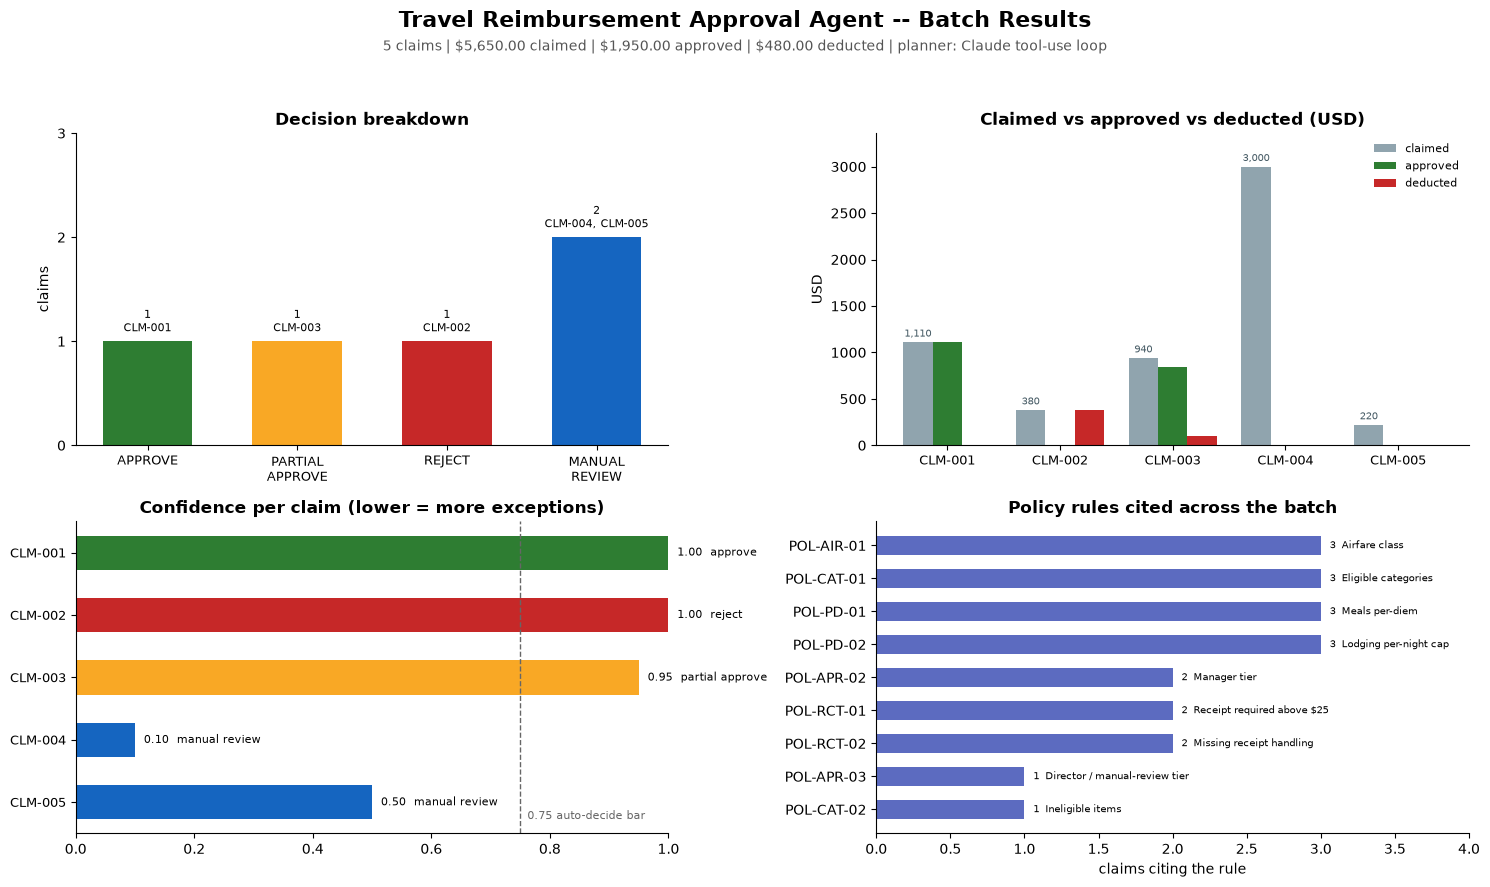

In [12]:
# =============================================================================
# 11. Results dashboard -- derived entirely from the actual claim outcomes
# =============================================================================
# Nothing here is hard-coded: every number is read back out of RESULTS / TRAILS.
# Saved next to the notebook as "UI SS_1.png" as the brief requests.

DASHBOARD_PNG = "UI SS_1.png"

DECISION_COLORS = {
    "APPROVE":         "#2E7D32",
    "PARTIAL_APPROVE": "#F9A825",
    "REJECT":          "#C62828",
    "MANUAL_REVIEW":   "#1565C0",
}

def render_dashboard(results, trails, save_as: Optional[str] = DASHBOARD_PNG):
    if not HAS_MPL:
        # Text dashboard -- the notebook still produces a data-driven summary.
        print("matplotlib unavailable; text dashboard:\n")
        counts: Dict[str, int] = {}
        for r in results:
            counts[r["decision"]] = counts.get(r["decision"], 0) + 1
        width = max(len(k) for k in counts)
        for k, v in sorted(counts.items(), key=lambda kv: -kv[1]):
            print(f"  {k:<{width}}  {'#' * v * 6} {v}")
        tot_c = sum(CLAIMS_BY_ID[r['claim_id']]['total_claimed'] for r in results)
        print(f"\n  claimed  ${tot_c:,.2f}")
        print(f"  approved ${sum(r['approved_amount'] for r in results):,.2f}")
        print(f"  deducted ${sum(r['deducted_amount'] for r in results):,.2f}")
        return None

    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    ids      = [r["claim_id"] for r in results]
    decs     = [r["decision"] for r in results]
    claimed  = [CLAIMS_BY_ID[r["claim_id"]]["total_claimed"] for r in results]
    approved = [r["approved_amount"] for r in results]
    deducted = [r["deducted_amount"] for r in results]
    confs    = [r["confidence"] for r in results]

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    fig.suptitle("Travel Reimbursement Approval Agent -- Batch Results",
                 fontsize=16, fontweight="bold", y=0.98)
    sub = (f"{len(results)} claims | ${sum(claimed):,.2f} claimed | "
           f"${sum(approved):,.2f} approved | ${sum(deducted):,.2f} deducted | "
           f"planner: {'Claude tool-use loop' if LLM_AVAILABLE else 'deterministic fallback'}")
    fig.text(0.5, 0.935, sub, ha="center", fontsize=10, color="#555")

    # --- 1. decision breakdown ------------------------------------------------
    ax = axes[0][0]
    order  = [d for d in DECISIONS if d in decs]
    counts = [decs.count(d) for d in order]
    bars = ax.bar(range(len(order)), counts,
                  color=[DECISION_COLORS[d] for d in order], width=0.6)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([d.replace("_", "\n") for d in order], fontsize=9)
    ax.set_title("Decision breakdown", fontweight="bold")
    ax.set_ylabel("claims")
    ax.set_ylim(0, max(counts) + 1)
    ax.set_yticks(list(range(0, max(counts) + 2)))
    for b, c, d in zip(bars, counts, order):
        members = ", ".join(i for i, dd in zip(ids, decs) if dd == d)
        ax.text(b.get_x() + b.get_width() / 2, c + 0.06, f"{c}\n{members}",
                ha="center", va="bottom", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    # --- 2. claimed vs approved vs deducted ----------------------------------
    ax = axes[0][1]
    x, w = range(len(ids)), 0.26
    ax.bar([i - w for i in x], claimed,  w, label="claimed",  color="#90A4AE")
    ax.bar(list(x),           approved, w, label="approved", color="#2E7D32")
    ax.bar([i + w for i in x], deducted, w, label="deducted", color="#C62828")
    ax.set_xticks(list(x))
    ax.set_xticklabels(ids, fontsize=9)
    ax.set_title("Claimed vs approved vs deducted (USD)", fontweight="bold")
    ax.set_ylabel("USD")
    ax.legend(fontsize=8, frameon=False)
    ax.set_ylim(0, max(claimed) * 1.12)
    for i, cl in enumerate(claimed):
        ax.text(i - w, cl + max(claimed) * 0.02, f"{cl:,.0f}",
                ha="center", fontsize=7.5, color="#455A64")
    ax.spines[["top", "right"]].set_visible(False)

    # --- 3. confidence + manual-review band ----------------------------------
    ax = axes[1][0]
    bars = ax.barh(list(range(len(ids))), confs,
                   color=[DECISION_COLORS[d] for d in decs], height=0.55)
    ax.set_yticks(list(range(len(ids))))
    ax.set_yticklabels(ids, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.0)
    ax.axvline(0.75, ls="--", lw=1, color="#666")
    ax.text(0.762, len(ids) - 0.78, "0.75 auto-decide bar", fontsize=8, color="#666", va="center")
    ax.set_title("Confidence per claim (lower = more exceptions)", fontweight="bold")
    for i, (b, c, d) in enumerate(zip(bars, confs, decs)):
        ax.text(c + 0.015, i, f"{c:.2f}  {d.replace('_', ' ').lower()}",
                va="center", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    # --- 4. which policy rules actually fired --------------------------------
    ax = axes[1][1]
    freq: Dict[str, int] = {}
    for r in results:
        for ref in r["policy_refs"]:
            freq[ref] = freq.get(ref, 0) + 1
    rows = sorted(freq.items(), key=lambda kv: (-kv[1], kv[0]))
    ax.barh([r[0] for r in rows][::-1], [r[1] for r in rows][::-1],
            color="#5C6BC0", height=0.6)
    ax.set_title("Policy rules cited across the batch", fontweight="bold")
    ax.set_xlabel("claims citing the rule")
    ax.set_xlim(0, max(freq.values()) + 1)
    for i, (ref, n) in enumerate(rows[::-1]):
        ax.text(n + 0.06, i, f"{n}  {POLICY_BY_ID[ref]['title']}", va="center", fontsize=7.5)
    ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout(rect=(0, 0, 1, 0.925))
    if save_as:
        fig.savefig(save_as, dpi=130, bbox_inches="tight", facecolor="white")
        print(f"Dashboard saved to '{save_as}'")
    return fig


_fig = render_dashboard(RESULTS, TRAILS)
if _fig is not None:
    try:
        import matplotlib.pyplot as plt
        plt.show()
    except Exception:
        pass

### Claim reviewer (interactive)

The means by which a user interacts with this notebook: pick a claim, inspect its decision and audit trail, or press **Re-run agent** to invoke the agent live on it. A static rendering of all five claims follows the widget, because interactive widgets do not render in a saved `.ipynb` or on GitHub.

In [13]:
# =============================================================================
# 12. Interactive claim reviewer -- the UI the brief asks for
# =============================================================================
# "This UI will be the means by which the user interacts with notebook code."
# Pick a claim, press Re-run: the agent is re-invoked live and prints the
# decision plus the full audit trail. Degrades to a static per-claim printout
# when ipywidgets is unavailable, so the notebook never breaks on a bare kernel.

def review_claim(claim_id: str, rerun: bool = False, show_trail: bool = True) -> None:
    """Render one claim: input, decision, audit trail."""
    claim = CLAIMS_BY_ID[claim_id]
    if rerun:
        decision, trail = evaluate_claim(claim_id)
    else:
        decision = next(r for r in RESULTS if r["claim_id"] == claim_id)
        trail    = TRAILS[claim_id]

    bar = {"APPROVE": "[ APPROVED ]", "PARTIAL_APPROVE": "[ PARTIALLY APPROVED ]",
           "REJECT": "[ REJECTED ]", "MANUAL_REVIEW": "[ MANUAL REVIEW ]"}[decision["decision"]]

    print("=" * 96)
    print(f" {claim_id}   {bar}   confidence {decision['confidence']:.2f}")
    print("=" * 96)
    print(f" Employee : {claim['employee']}")
    print(f" Purpose  : {claim['purpose']}")
    print(f" Trip     : {claim['trip_start']} to {claim['trip_end']}   "
          f"submitted {claim['submitted_on']}")
    print("-" * 96)
    print(f" {'LINE':<5}{'CATEGORY':<18}{'AMOUNT':>11}  {'RECEIPT':<9}DESCRIPTION")
    for li in claim["line_items"]:
        print(f" {li['line_id']:<5}{li['category']:<18}{li['amount']:>11,.2f}  "
              f"{('yes' if li['receipt_attached'] else 'MISSING'):<9}{li['description']}")
    print("-" * 96)
    print(f" {'':<23}{'claimed':>11}{'approved':>13}{'deducted':>13}")
    print(f" {'':<23}{claim['total_claimed']:>11,.2f}"
          f"{decision['approved_amount']:>13,.2f}{decision['deducted_amount']:>13,.2f}")
    print("-" * 96)
    print(" POLICY REFS : " + ", ".join(decision["policy_refs"]))
    print(" TOOLS USED  : " + ", ".join(decision["tools_used"]))
    if decision["missing_docs"]:
        print(" MISSING     : " + "\n               ".join(decision["missing_docs"]))
    print("\n EXPLANATION")
    print(textwrap.indent(textwrap.fill(decision["explanation"], 88), "   "))
    if show_trail:
        print()
        print_audit_trail(trail)
    print()


if HAS_WIDGETS:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    _picker = widgets.Dropdown(
        options=[(f"{c['claim_id']}  --  {c['purpose'][:46]}", c["claim_id"]) for c in CLAIMS],
        value=CLAIMS[0]["claim_id"], description="Claim:",
        layout=widgets.Layout(width="620px"),
        style={"description_width": "60px"},
    )
    _rerun_btn = widgets.Button(description="Re-run agent", button_style="primary",
                                icon="refresh", layout=widgets.Layout(width="150px"))
    _out = widgets.Output()

    def _render(rerun=False):
        with _out:
            clear_output(wait=True)
            if rerun:
                print(f"Re-running the agent on {_picker.value} "
                      f"({'live LLM call' if LLM_AVAILABLE else 'deterministic planner'}) ...\n")
            review_claim(_picker.value, rerun=rerun)

    _picker.observe(lambda ch: _render(False) if ch["name"] == "value" else None, names="value")
    _rerun_btn.on_click(lambda _b: _render(True))

    display(widgets.HTML(
        "<h3 style='margin-bottom:4px'>Travel Reimbursement Approval Agent &mdash; Claim Reviewer</h3>"
        "<div style='color:#666;font-size:13px;margin-bottom:8px'>"
        "Select a claim to inspect its decision and audit trail. "
        "<b>Re-run agent</b> invokes the agent live on that claim.</div>"))
    display(widgets.HBox([_picker, _rerun_btn]))
    display(_out)
    _render(False)
else:
    print("ipywidgets is unavailable in this kernel -- the static rendering below "
          "carries exactly the same information.")

# Static rendering, emitted unconditionally. Interactive widgets do not render in a
# saved .ipynb or on GitHub, so a reviewer reading this file still sees the interface.
print()
print("#" * 96)
print("# STATIC RENDERING OF THE CLAIM REVIEWER -- all five claims")
print("# (shown unconditionally: ipywidgets do not render in a saved notebook or on GitHub)")
print("#" * 96)
print()
for _c in CLAIMS:
    review_claim(_c["claim_id"], show_trail=False)

HTML(value="<h3 style='margin-bottom:4px'>Travel Reimbursement Approval Agent &mdash; Claim Reviewer</h3><div …

Output()


################################################################################################
# STATIC RENDERING OF THE CLAIM REVIEWER -- all five claims
# (shown unconditionally: ipywidgets do not render in a saved notebook or on GitHub)
################################################################################################

 CLM-001   [ APPROVED ]   confidence 1.00
 Employee : A. Rivera
 Purpose  : Attend 2-day industry conference (business)
 Trip     : 2026-06-10 to 2026-06-12   submitted 2026-06-20
------------------------------------------------------------------------------------------------
 LINE CATEGORY               AMOUNT  RECEIPT  DESCRIPTION
 L1   airfare                420.00  yes      Round-trip economy airfare
 L2   lodging                360.00  yes      Hotel, 2 nights @ $180
 L3   meals                  180.00  yes      Meals, 3 days @ ~$60/day
 L4   conference_fees        150.00  yes      Conference registration
-----------------------------------------

---

## 11. Evaluation harness

An executable statement of what *correct* means, derived by hand from Appendix A and asserted against what the agent actually produced. The final `assert` is the gate that stops a silently wrong result reaching the last cell.

In [14]:
# =============================================================================
# 13. Evaluation harness -- the expected-decision test suite
# =============================================================================
# An assignment that grades "business correctness" deserves an executable
# statement of what correct means. These expectations are derived from Appendix
# A by hand and asserted against whatever the agent actually produced, so a
# regression in the rules or a drifting prompt fails loudly instead of quietly.
#
# policy_refs is asserted as a SUBSET (the agent may legitimately cite more
# context than the minimum); decision and amounts are asserted exactly.

EXPECTED = {
    "CLM-001": {"decision": "APPROVE",         "approved": 1110.00, "deducted":   0.00,
                "missing": 0, "refs": {"POL-CAT-01", "POL-PD-01", "POL-PD-02", "POL-APR-02"},
                "why": "all eligible, all receipted, every line within cap, $1,110 in the manager tier"},
    "CLM-002": {"decision": "REJECT",          "approved":    0.00, "deducted": 380.00,
                "missing": 0, "refs": {"POL-CAT-02"},
                "why": "spa + minibar are both ineligible; nothing is reimbursable"},
    "CLM-003": {"decision": "PARTIAL_APPROVE", "approved":  840.00, "deducted": 100.00,
                "missing": 0, "refs": {"POL-PD-02", "POL-APR-02"},
                "why": "$250/night lodging against the $200 cap -> $100 deducted"},
    "CLM-004": {"decision": "MANUAL_REVIEW",   "approved":    0.00, "deducted":   0.00,
                "missing": 1, "refs": {"POL-AIR-01", "POL-RCT-02", "POL-APR-03"},
                "why": "business class + missing lodging receipt + $3,000 over the director threshold"},
    "CLM-005": {"decision": "MANUAL_REVIEW",   "approved":    0.00, "deducted":   0.00,
                "missing": 1, "refs": {"POL-RCT-01", "POL-RCT-02"},
                "why": "$220 meal over $25 with no receipt -> documentation request, not a deduction"},
}

def run_eval_suite(results) -> Tuple[int, int, List[str]]:
    by_id = {r["claim_id"]: r for r in results}
    passed, failed, failures = 0, 0, []

    def check(label, cond, detail=""):
        nonlocal passed, failed
        if cond:
            passed += 1
        else:
            failed += 1
            failures.append(f"{label}: {detail}")
        return cond

    print(f"{'CLAIM':<9}{'CHECK':<34}{'RESULT'}")
    print("-" * 96)
    for cid, exp in EXPECTED.items():
        got = by_id.get(cid)
        if got is None:
            check(cid, False, "no result produced")
            continue
        rows = [
            ("decision",        got["decision"] == exp["decision"],
             f"expected {exp['decision']}, got {got['decision']}"),
            ("approved_amount", abs(got["approved_amount"] - exp["approved"]) < 0.01,
             f"expected {exp['approved']:,.2f}, got {got['approved_amount']:,.2f}"),
            ("deducted_amount", abs(got["deducted_amount"] - exp["deducted"]) < 0.01,
             f"expected {exp['deducted']:,.2f}, got {got['deducted_amount']:,.2f}"),
            ("missing_docs count", len(got["missing_docs"]) == exp["missing"],
             f"expected {exp['missing']}, got {len(got['missing_docs'])}"),
            ("policy_refs superset", exp["refs"].issubset(set(got["policy_refs"])),
             f"missing {sorted(exp['refs'] - set(got['policy_refs']))}"),
            ("schema valid", output_validator(got)["valid"],
             str(output_validator(got)["errors"])),
            ("tools_used >= 2", len(got["tools_used"]) >= 2,
             f"only {len(got['tools_used'])} tools"),
        ]
        for name, ok, detail in rows:
            check(f"{cid}.{name}", ok, detail)
            print(f"{cid:<9}{name:<34}{'PASS' if ok else 'FAIL  ' + detail}")
        print(f"{'':<9}{'-> ' + exp['why']}")
        print()

    # batch-level invariants
    print("-" * 96)
    total_claimed = sum(c["total_claimed"] for c in CLAIMS)
    committed     = sum(r["approved_amount"] + r["deducted_amount"] for r in results
                        if r["decision"] != "MANUAL_REVIEW")
    non_mr        = sum(CLAIMS_BY_ID[r["claim_id"]]["total_claimed"] for r in results
                        if r["decision"] != "MANUAL_REVIEW")
    inv = [
        ("every claim produced exactly one result", len(results) == len(CLAIMS),
         f"{len(results)} results for {len(CLAIMS)} claims"),
        ("no MANUAL_REVIEW commits money",
         all(r["approved_amount"] == 0 and r["deducted_amount"] == 0
             for r in results if r["decision"] == "MANUAL_REVIEW"), ""),
        ("decided claims reconcile to the claimed total",
         abs(committed - non_mr) < 0.01, f"{committed:,.2f} vs {non_mr:,.2f}"),
        ("every policy_ref exists in the corpus",
         all(ref in POLICY_BY_ID for r in results for ref in r["policy_refs"]), ""),
        ("field set matches the contract exactly",
         all(set(r) == set(REQUIRED_FIELDS) for r in results), ""),
    ]
    for name, ok, detail in inv:
        check(f"batch.{name}", ok, detail)
        print(f"{'BATCH':<9}{name:<52}{'PASS' if ok else 'FAIL  ' + detail}")

    print("-" * 96)
    print(f"\nTotal claimed across the batch: ${total_claimed:,.2f}")
    return passed, failed, failures


_passed, _failed, _failures = run_eval_suite(RESULTS)
print(f"\n{'=' * 96}")
print(f"EVAL SUITE: {_passed} passed, {_failed} failed")
print("=" * 96)
for _f in _failures:
    print(f"  FAILED -- {_f}")

assert _failed == 0, f"{_failed} expectation(s) failed: {_failures}"
print("\nAll expectations hold. The notebook is self-verifying: this assert is the gate "
      "that stops a silently wrong result reaching the final cell.")

CLAIM    CHECK                             RESULT
------------------------------------------------------------------------------------------------
CLM-001  decision                          PASS
CLM-001  approved_amount                   PASS
CLM-001  deducted_amount                   PASS
CLM-001  missing_docs count                PASS
CLM-001  policy_refs superset              PASS
CLM-001  schema valid                      PASS
CLM-001  tools_used >= 2                   PASS
         -> all eligible, all receipted, every line within cap, $1,110 in the manager tier

CLM-002  decision                          PASS
CLM-002  approved_amount                   PASS
CLM-002  deducted_amount                   PASS
CLM-002  missing_docs count                PASS
CLM-002  policy_refs superset              PASS
CLM-002  schema valid                      PASS
CLM-002  tools_used >= 2                   PASS
         -> spa + minibar are both ineligible; nothing is reimbursable

CLM-003  decision

## Design Notes & Reasoning

### The one decision everything else follows from

The brief grades both *agentic AI* (tool calling, workflow control, prompting) and
*business correctness* (sensible decisions grounded in policy). Those two pull in
opposite directions. An LLM given free rein over the arithmetic will usually compute
`$500 − 2 × $200 = $100` correctly and occasionally will not, and a reimbursement
system that is occasionally wrong about money is worse than useless.

So the split here is: **the LLM orchestrates, deterministic tools decide the money.**

The model genuinely drives the workflow — it is handed eight tools and no script,
and it chooses what to call, in what order, when it has enough evidence, and how to
reconcile signals that point different ways. On CLM-004 it independently found three
separate manual-review triggers and a fourth data conflict, then called
`output_validator`, failed, fixed its own payload, and resubmitted. That is the
agentic behaviour the assignment is asking to see.

What the model is *not* allowed to do is invent a number, invent a policy id, or talk
itself past a manual-review gate. Section 8 re-runs the rule engine as a referee and
overrules the model on decision and amounts, logging any divergence rather than hiding
it. The model keeps ownership of the explanation and the confidence — the parts where
natural language genuinely beats a template.

### Why each case routes where it does

| Claim | Decision | Reasoning |
|---|---|---|
| CLM-001 | `APPROVE` | Every item eligible, every receipt present, lodging $360 against a 2-night × $200 = $400 cap, meals $180 against a 3-day × $75 = $225 cap. $1,110 sits in the manager tier (POL-APR-02). |
| CLM-002 | `REJECT` | Spa and minibar are both POL-CAT-02. Nothing is reimbursable, so the full $380 is deducted. This is the one case where `REJECT` is right rather than `MANUAL_REVIEW` — there is no ambiguity to resolve. |
| CLM-003 | `PARTIAL_APPROVE` | $500 lodging against a 2-night × $200 cap. $100 over, deducted; the remaining $840 is approvable. Meals at $70/day stay under the $75 cap. |
| CLM-004 | `MANUAL_REVIEW` | Three independent triggers plus a data conflict: business-class airfare (POL-AIR-01), missing lodging receipt (POL-RCT-02), $3,000 over the $2,000 director threshold (POL-APR-03) — and the line says "3 nights" while the trip dates span 2. |
| CLM-005 | `MANUAL_REVIEW` | **The interesting one.** |

### Why CLM-005 is not a partial approval

A $220 client dinner on a one-day trip is nearly three times the $75 daily meal cap,
so the tempting answer is `PARTIAL_APPROVE` with $75 approved and $145 deducted. That
is wrong. The item is over $25 and has no receipt, and POL-RCT-01 → POL-RCT-02 says
plainly that a missing receipt means the item "is not silently rejected — the claim is
routed to Manual Review so the reviewer can request the receipt."

Deducting $145 would be exactly the silent rejection the policy forbids. Worse, it
would be *unrecoverable*: the employee gets $75 and no signal that a receipt would have
changed the outcome. So the receipt gate is evaluated **before** per-diem scoring, and
the provisional $75 / $145 split is carried in the audit trail for the reviewer to use
once the receipt arrives.

This is the generalisation: **a missing document is a question, not a verdict.**

### What routes to Manual Review, and why that list is short

Six triggers, and each one is a case where more information would change the answer:

- **Missing required receipt** — the reviewer can obtain it.
- **Business/first-class airfare** — the policy says explicitly not to auto-deduct,
  because a pre-approval may exist that the agent cannot see.
- **Total over $2,000** — a stated limit on the agent's authority, not a judgement.
- **Late submission** — an exception someone may have granted out of band.
- **Suspected duplicate / unclassifiable category / self-contradictory claim data** —
  the agent's inputs are inconsistent, so any decision would be built on sand.

For all of them `approved_amount` and `deducted_amount` are `0.00`: nothing is
committed until a human decides. The provisional computation is not thrown away — it
is on the audit trail and quoted in the explanation, so the reviewer starts from the
agent's work rather than from scratch.

The temptation is to add more triggers "to be safe". Every extra trigger is a claim a
human now has to touch, and an approval agent that escalates everything has automated
nothing. Six is the set the policy actually justifies.

### Trade-offs I made deliberately

**Lexical retrieval instead of embeddings.** Twelve short rules, controlled vocabulary
("minibar", "economy", "receipt"). TF-IDF resolves them cleanly with no network call
and no vector store. Embeddings solve a paraphrase problem this corpus does not have.
This is the first thing to revisit if the policy grows to hundreds of rules.

**A hand-written tool loop instead of the SDK's tool runner.** The runner is a beta API
that would hide the request → execute → feed-back cycle the assignment is grading, and
owning the loop is what makes the per-call audit trail possible.

**No agent framework.** LangChain or CrewAI would have added a dependency, a version
surface, and an abstraction layer over roughly sixty lines of loop. The brief asks for
"avoidable over-engineering removed".

**Per-diem caps aggregate across the trip.** The policy states daily and nightly caps;
the claims give one aggregated line per category ("Meals, 3 days @ ~$60/day"). Capping
meals at $75 × trip_days is the only reading consistent with both. Per-line daily data
would let this be exact, and the tool is written so that switching is a one-line change.

**Everything embedded in the notebook.** Policy, claims, and tools are literals rather
than files, because the deliverable is a single notebook that must run top-to-bottom
on a reviewer's machine. Intake still goes through `load_claims_from_json`, so pointing
it at a real file or an API body changes one line.

### Assumptions

1. Per-diem caps apply per category aggregate across the trip, not per line item.
2. Lodging nights = `trip_end − trip_start`; per-diem days = the inclusive span
   (a same-day trip is one day).
3. The 30-day submission window runs from the trip end date — the latest expense date
   present in the provided data.
4. `MANUAL_REVIEW` commits no money; the provisional split lives in the audit trail.
5. `duplicate_detector` is scoped to the provided batch. There is no claim history in
   the assignment data and the brief forbids inventing claims, so it demonstrates the
   capability against real data rather than fabricated history.
6. Single currency (USD). No FX, no tax handling.
7. Airfare class is inferred from the line description, which is the only signal
   present in the data.

### Known gaps

- **No receipt parsing.** `receipt_attached` is a boolean in the input; there is no OCR
  and no check that an attached receipt actually matches the claimed amount, vendor, or
  date. An employee could attach the wrong receipt and pass every check here.
- **Duplicate detection is intra-batch only** and matches on an exact
  (employee, category, amount, trip start) signature. Near-duplicates — same dinner
  split across two claims, or claimed by two attendees — are invisible to it.
- **No policy versioning.** Claims are judged against today's policy, not the policy in
  force on the expense date.
- **Confidence is a rule-derived heuristic**, not a calibrated probability. It is
  useful for ranking a review queue; it should not be read as "70% likely correct".
- **The agentic path is non-deterministic.** The rule engine pins the decision and the
  amounts, so the graded output is stable, but the explanation text varies run to run.
- **No persistence, no reviewer feedback loop.** Overturned decisions teach the system
  nothing.
- **MCP tool integration was scoped out** to protect notebook runnability inside the
  2–3 day timebox. The tool layer is already pure JSON-in/JSON-out, so exposing it over
  MCP is a wrapper, not a redesign.

### What I would build next, in order

1. **Receipt ingestion with a vision model** — extract vendor, date, line items and
   total from the attached image, then reconcile against the claim. This is the single
   biggest correctness gap, and it converts several `MANUAL_REVIEW` routes into
   automated decisions.
2. **A real claims store** so `duplicate_detector` works across history and across
   employees, with fuzzy matching on vendor and date rather than exact signatures.
3. **Effective-dated policy versions**, so a claim is always judged under the policy in
   force on its expense date, and so a policy change is auditable.
4. **Calibrate confidence against reviewer outcomes.** Log every manual review and what
   the human decided; fit the thresholds to the observed overturn rate instead of the
   hand-picked penalties used here.
5. **Track the LLM / rule-engine agreement rate as a production alarm.** It is already
   computed and shown in the dashboard. A drop in it is the earliest signal that a
   prompt, a model version, or the policy has drifted.
6. **Expose the tool layer over MCP** so the same checks can be reused by other agents
   and by a chat interface, without duplicating the rules.

---

## Final results

The JSON array, one object per provided claim, with exactly the nine fields specified in Section 3 of the assignment.

In [15]:
# =============================================================================
# FINAL CELL -- the graded artifact
# =============================================================================
# One JSON array, one object per provided claim, with exactly the nine fields
# specified in Section 3 of the assignment:
#   claim_id, decision, approved_amount, deducted_amount, missing_docs,
#   policy_refs, confidence, explanation, tools_used

FINAL_RESULTS = [{k: r[k] for k in REQUIRED_FIELDS} for r in RESULTS]

# last-chance contract check before printing
for _r in FINAL_RESULTS:
    _ok, _errs = validate_decision(_r)
    assert _ok, f"{_r['claim_id']} violates the output contract: {_errs}"
assert len(FINAL_RESULTS) == len(CLAIMS), "one result object per provided claim"

print(json.dumps(FINAL_RESULTS, indent=2))

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02"
    ],
    "confidence": 1.0,
    "explanation": "Claim for 2-day conference travel is fully compliant: submitted within 30 days (POL-TIME-01), all line items have itemized receipts (POL-RCT-01), airfare is economy class and fully reimbursable (POL-AIR-01, POL-CAT-01), lodging ($180/night) is under the $200/night cap (POL-PD-02), and meals (~$60/day) are under the $75/day cap (POL-PD-01). No duplicates detected. Total of $1,110.00 approved in full, falling within manager approval tier (POL-APR-02).",
    "tools_used": [
      "receipt_completeness_check",
      "per_diem_limit_checker",
      "timeliness_check",
      "duplicate_detector",
      "approval_threshold_check",
      "policy_lookup",
      "output_validator",
      "s